# Veri Ön İşleme ve Graph Oluşturma

Bu notebook'ta CTU-13 Botnet Dataset kullanılarak ağ trafiği verisi graph yapısına dönüştürülmüştür.

Çalışmanın temel amacı, IP adresleri arasındaki bağlantıları düğüm ve kenar yapısı ile temsil etmek, zaman bilgisine göre ağı parçalara ayırmak ve temporal network analizi için temel graph yapısını oluşturmaktır.

Bu notebook kapsamında yapılan işlemler:

- Veri setinin yüklenmesi
- Kolonların incelenmesi
- Timestamp bilgisinin dönüştürülmesi
- Kaynak IP ve hedef IP üzerinden kenar listesinin oluşturulması
- Verinin zaman dilimlerine ayrılması
- NetworkX ile yönlü/ağırlıklı graph oluşturulması
- İlk ağ görselleştirmesinin yapılması

Bu notebook, sonraki aşamalarda yapılacak merkezilik analizi, topluluk analizi, stealth-like node tespiti ve zamansal ağ karşılaştırmaları için temel hazırlık aşamasıdır.

In [3]:
import pandas as pd
import numpy as np

import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None) #veri tablosundaki tüm sütunları göster
pd.set_option("display.max_rows", 100) #max 100 satır göster

In [4]:
BASE_DIR = Path("..")

RAW_DATA_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

data_path = RAW_DATA_DIR / "capture20110818.binetflow"

In [5]:
df = pd.read_csv(data_path)

print("Veri seti boyutu:", df.shape)
df.head()

Veri seti boyutu: (1309791, 33)


,SrcAddr,DstAddr,Proto,Sport,Dport,State,sTos,dTos,SrcWin,DstWin,sHops,dHops,StartTime,LastTime,sTtl,dTtl,TcpRtt,SynAck,AckDat,SrcPkts,DstPkts,SrcBytes,DstBytes,SAppBytes,DAppBytes,Dur,TotPkts,TotBytes,TotAppByte,Rate,SrcRate,DstRate,Label
0,93.45.239.29,147.32.84.118,tcp,1611,6881,RST,0.0,0.0,65535.0,0.0,22.0,1.0,2011/08/18 10:21:46.633335,2011/08/18 10:21:47.693583,42.0,63.0,0.000000,0.000000,0.0,2,2,132,120,0,0,1.060248,4,252,0,2.829527,0.943176,1.783774,flow=Background-TCP-Attempt
1,62.240.166.118,147.32.84.229,tcp,1031,13363,RST,0.0,0.0,65340.0,65296.0,13.0,1.0,2011/08/18 10:19:49.027650,2011/08/18 10:24:28.376815,115.0,127.0,0.000000,0.000000,0.0,9,6,955,363,437,24,279.349152,15,1318,461,0.050116,0.028638,0.052161,flow=Background-TCP-Attempt
2,147.32.86.148,66.235.132.232,tcp,58067,80,RST,0.0,0.0,747520.0,4380.0,1.0,18.0,2011/08/18 10:22:07.160628,2011/08/18 10:24:53.550637,63.0,238.0,0.192812,0.192812,0.0,2,1,134,78,0,0,166.390015,3,212,0,0.012020,0.006010,0.000000,flow=Background-TCP-Established
3,147.32.3.51,147.32.84.46,tcp,3130,10010,RST,0.0,0.0,65535.0,0.0,5.0,1.0,2011/08/18 10:26:02.052163,2011/08/18 10:26:03.239246,123.0,63.0,0.000000,0.000000,0.0,2,2,124,120,0,0,1.187083,4,244,0,2.527203,0.842401,1.562073,flow=Background-TCP-Attempt
4,88.212.37.169,147.32.84.118,tcp,3134,6881,RST,0.0,0.0,65535.0,0.0,13.0,1.0,2011/08/18 10:26:52.226748,2011/08/18 10:26:53.207319,115.0,63.0,0.000000,0.000000,0.0,2,2,124,120,0,0,0.980571,4,244,0,3.059442,1.019814,2.092304,flow=Background-TCP-Attempt


In [4]:
df.columns

Index(['SrcAddr', 'DstAddr', 'Proto', 'Sport', 'Dport', 'State', 'sTos',
       'dTos', 'SrcWin', 'DstWin', 'sHops', 'dHops', 'StartTime', 'LastTime',
       'sTtl', 'dTtl', 'TcpRtt', 'SynAck', 'AckDat', 'SrcPkts', 'DstPkts',
       'SrcBytes', 'DstBytes', 'SAppBytes', 'DAppBytes', 'Dur', 'TotPkts',
       'TotBytes', 'TotAppByte', 'Rate', 'SrcRate', 'DstRate', 'Label'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309791 entries, 0 to 1309790
Data columns (total 33 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   SrcAddr     1309791 non-null  str    
 1   DstAddr     1309791 non-null  str    
 2   Proto       1309791 non-null  str    
 3   Sport       1308067 non-null  str    
 4   Dport       1308077 non-null  str    
 5   State       1308563 non-null  str    
 6   sTos        1296939 non-null  float64
 7   dTos        1123000 non-null  float64
 8   SrcWin      319227 non-null   float64
 9   DstWin      298000 non-null   float64
 10  sHops       1296939 non-null  float64
 11  dHops       1123000 non-null  float64
 12  StartTime   1309791 non-null  str    
 13  LastTime    1309791 non-null  str    
 14  sTtl        1296939 non-null  float64
 15  dTtl        1123000 non-null  float64
 16  TcpRtt      1309791 non-null  float64
 17  SynAck      1309791 non-null  float64
 18  AckDat      1309791 non-null  flo

In [5]:
# veri seti istatistikleri
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SrcAddr,1309791,151256,147.32.84.138,211967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DstAddr,1309791,72957,147.32.80.9,483049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Proto,1309791,14,udp,851563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sport,1308067,114794,13363,68038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dport,1308077,47047,53,495780,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,1308563,58,CON,827442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sTos,1296939.0,NaN,NaN,NaN,0.042777,2.82638,0.0,0.0,0.0,0.0,192.0
dTos,1123000.0,NaN,NaN,NaN,0.000453,0.034138,0.0,0.0,0.0,0.0,3.0
SrcWin,319227.0,NaN,NaN,NaN,193286.455306,3543178.75767,0.0,28288.0,65224.0,65700.0,1073725440.0
DstWin,298000.0,NaN,NaN,NaN,158052.327,7144267.987935,0.0,6912.0,10240.0,65379.0,533790720.0


In [6]:
selected_columns = [
    "StartTime",
    "Dur",
    "Proto",
    "SrcAddr",
    "Sport",
    "DstAddr",
    "Dport",
    "State",
    "SrcPkts",
    "DstPkts",
    "TotPkts",
    "TotBytes",
    "SrcBytes",
    "Label"
]

df = df[selected_columns].copy()

df.head()

,StartTime,Dur,Proto,SrcAddr,Sport,DstAddr,Dport,State,SrcPkts,DstPkts,TotPkts,TotBytes,SrcBytes,Label
0,2011/08/18 10:21:46.633335,1.060248,tcp,93.45.239.29,1611,147.32.84.118,6881,RST,2,2,4,252,132,flow=Background-TCP-Attempt
1,2011/08/18 10:19:49.027650,279.349152,tcp,62.240.166.118,1031,147.32.84.229,13363,RST,9,6,15,1318,955,flow=Background-TCP-Attempt
2,2011/08/18 10:22:07.160628,166.390015,tcp,147.32.86.148,58067,66.235.132.232,80,RST,2,1,3,212,134,flow=Background-TCP-Established
3,2011/08/18 10:26:02.052163,1.187083,tcp,147.32.3.51,3130,147.32.84.46,10010,RST,2,2,4,244,124,flow=Background-TCP-Attempt
4,2011/08/18 10:26:52.226748,0.980571,tcp,88.212.37.169,3134,147.32.84.118,6881,RST,2,2,4,244,124,flow=Background-TCP-Attempt


In [7]:
# kolon isimlerini düzenleme
df.columns = [
    "timestamp",
    "duration",
    "protocol",
    "src_ip",
    "src_port",
    "dst_ip",
    "dst_port",
    "state",
    "src_packets",
    "dst_packets",
    "total_packets",
    "total_bytes",
    "src_bytes",
    "label"
]

df.head()

,timestamp,duration,protocol,src_ip,src_port,dst_ip,dst_port,state,src_packets,dst_packets,total_packets,total_bytes,src_bytes,label
0,2011/08/18 10:21:46.633335,1.060248,tcp,93.45.239.29,1611,147.32.84.118,6881,RST,2,2,4,252,132,flow=Background-TCP-Attempt
1,2011/08/18 10:19:49.027650,279.349152,tcp,62.240.166.118,1031,147.32.84.229,13363,RST,9,6,15,1318,955,flow=Background-TCP-Attempt
2,2011/08/18 10:22:07.160628,166.390015,tcp,147.32.86.148,58067,66.235.132.232,80,RST,2,1,3,212,134,flow=Background-TCP-Established
3,2011/08/18 10:26:02.052163,1.187083,tcp,147.32.3.51,3130,147.32.84.46,10010,RST,2,2,4,244,124,flow=Background-TCP-Attempt
4,2011/08/18 10:26:52.226748,0.980571,tcp,88.212.37.169,3134,147.32.84.118,6881,RST,2,2,4,244,124,flow=Background-TCP-Attempt


In [8]:
df.isnull().sum()

timestamp           0
duration            0
protocol            0
src_ip              0
src_port         1724
dst_ip              0
dst_port         1714
state            1228
src_packets         0
dst_packets         0
total_packets       0
total_bytes         0
src_bytes           0
label               0
dtype: int64

In [9]:
# null değerleri tamamlama
df["src_port"] = df["src_port"].fillna("unknown")
df["dst_port"] = df["dst_port"].fillna("unknown")
df["state"] = df["state"].fillna("unknown")

df.isnull().sum()

timestamp        0
duration         0
protocol         0
src_ip           0
src_port         0
dst_ip           0
dst_port         0
state            0
src_packets      0
dst_packets      0
total_packets    0
total_bytes      0
src_bytes        0
label            0
dtype: int64

In [8]:
# timestamp'leri tarih-saat forrmatına dönüştürme
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

df = df.dropna(subset=["timestamp"])

print("Timestamp dönüştürme sonrası veri boyutu:", df.shape)
df[["timestamp"]].head()

Timestamp dönüştürme sonrası veri boyutu: (1309791, 14)


,timestamp
0,2011-08-18 10:21:46.633335
1,2011-08-18 10:19:49.027650
2,2011-08-18 10:22:07.160628
3,2011-08-18 10:26:02.052163
4,2011-08-18 10:26:52.226748


In [9]:
# sayısal verileri integer/float formatına çevirme, null değerleri 0 yapma
numeric_columns = [
    "duration",
    "src_packets",
    "dst_packets",
    "total_packets",
    "total_bytes",
    "src_bytes"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_columns] = df[numeric_columns].fillna(0)

df[numeric_columns].describe()

,duration,src_packets,dst_packets,total_packets,total_bytes,src_bytes
count,1.309791e+06,1.309791e+06,1.309791e+06,1.309791e+06,1.309791e+06,1.309791e+06
mean,2.538714e+02,2.159968e+01,2.691259e+01,4.851227e+01,3.695596e+04,8.064216e+03
std,7.694298e+02,1.802407e+03,2.780408e+03,4.419512e+03,3.821740e+06,1.253815e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,6.000000e+01,0.000000e+00
25%,2.610000e-04,1.000000e+00,1.000000e+00,2.000000e+00,2.140000e+02,7.900000e+01
50%,8.780000e-04,1.000000e+00,1.000000e+00,2.000000e+00,3.220000e+02,9.000000e+01
75%,2.277852e+00,4.000000e+00,3.000000e+00,6.000000e+00,1.066000e+03,9.290000e+02
max,3.600019e+03,8.164060e+05,1.250316e+06,1.853001e+06,1.933022e+09,1.233900e+09


In [10]:
# label inceleme
df["label"].value_counts()

label
flow=To-Background-UDP-CVUT-DNS-Server               478151
flow=Background-UDP-Established                      303963
flow=Background-TCP-Established                      170192
flow=Background-Established-cmpgw-CVUT                93215
flow=Background                                       31625
                                                      ...  
flow=From-Botnet-V51-5-TCP-CC1-HTTP-Not-Encrypted         1
flow=From-Botnet-V51-8-TCP-Established                    1
flow=From-Botnet-V51-9-TCP-CC1-HTTP-Not-Encrypted         1
flow=From-Botnet-V51-8-TCP-CC1-HTTP-Not-Encrypted         1
flow=From-Botnet-V51-1-TCP-Established                    1
Name: count, Length: 111, dtype: int64

In [18]:
df["is_botnet"] = df["label"].str.contains("Botnet", case=False, na=False).astype(int)

df["is_botnet"].value_counts()

is_botnet
0    1203439
1     106352
Name: count, dtype: int64

In [18]:
# zaman aralığını inceleme
print("Başlangıç zamanı:", df["timestamp"].min())
print("Bitiş zamanı:", df["timestamp"].max())
print("Toplam süre:", df["timestamp"].max() - df["timestamp"].min())

Başlangıç zamanı: 2011-08-18 09:56:29.146156
Bitiş zamanı: 2011-08-18 15:04:59.744388
Toplam süre: 0 days 05:08:30.598232


In [13]:
#veriyi 5 dakikalık zaman dilimlerine ayırma
df = df.sort_values("timestamp")

df["time_window"] = df["timestamp"].dt.floor("5min")

df[["timestamp", "time_window", "src_ip", "dst_ip"]].head()

,timestamp,time_window,src_ip,dst_ip
47877,2011-08-18 09:56:29.146156,2011-08-18 09:55:00,71.222.124.71,147.32.84.59
38292,2011-08-18 09:56:42.630892,2011-08-18 09:55:00,78.234.54.245,147.32.84.59
61953,2011-08-18 09:56:44.640650,2011-08-18 09:55:00,31.147.120.139,147.32.84.59
83287,2011-08-18 10:10:52.782230,2011-08-18 10:10:00,118.5.35.64,147.32.84.59
129,2011-08-18 10:19:13.328372,2011-08-18 10:15:00,147.32.86.166,212.24.150.110


In [14]:
# her 5 dk'Lık time window'da kaç bağlantı var
df["time_window"].value_counts().sort_index().head()

time_window
2011-08-18 09:55:00        3
2011-08-18 10:10:00        1
2011-08-18 10:15:00     4852
2011-08-18 10:20:00    24833
2011-08-18 10:25:00    24377
Name: count, dtype: int64

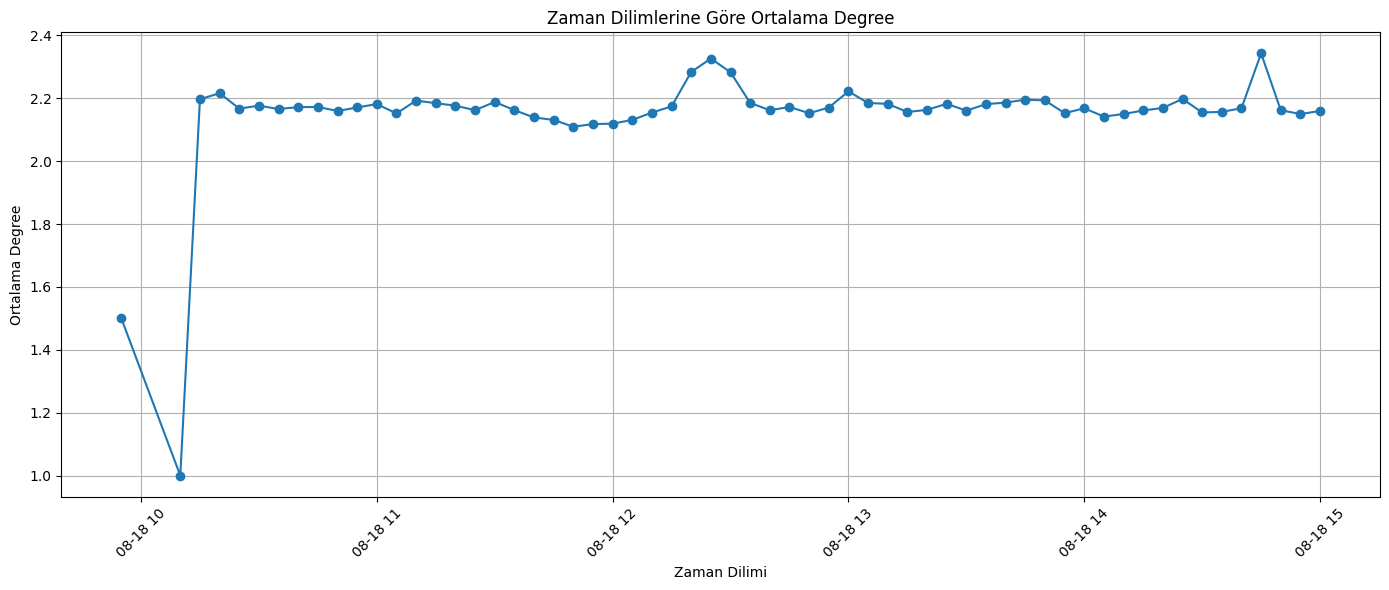

In [15]:
# zaman dilimlerine göre ortalama derece
avg_degree_list = []
time_labels = []

for time_window, group in df.groupby("time_window"):

    G_temp = nx.from_pandas_edgelist(  #her zaman dilimi için graph oluştur
        group,
        source="src_ip",
        target="dst_ip",
        create_using=nx.DiGraph()
    )

    degrees = dict(G_temp.degree()) #her düğümün bağlantı sayısını hesapla

    avg_degree = np.mean(list(degrees.values())) if len(degrees) > 0 else 0

    avg_degree_list.append(avg_degree)
    time_labels.append(time_window)

plt.figure(figsize=(14, 6))
plt.plot(time_labels, avg_degree_list, marker="o")

plt.title("Zaman Dilimlerine Göre Ortalama Degree")
plt.xlabel("Zaman Dilimi")
plt.ylabel("Ortalama Degree")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

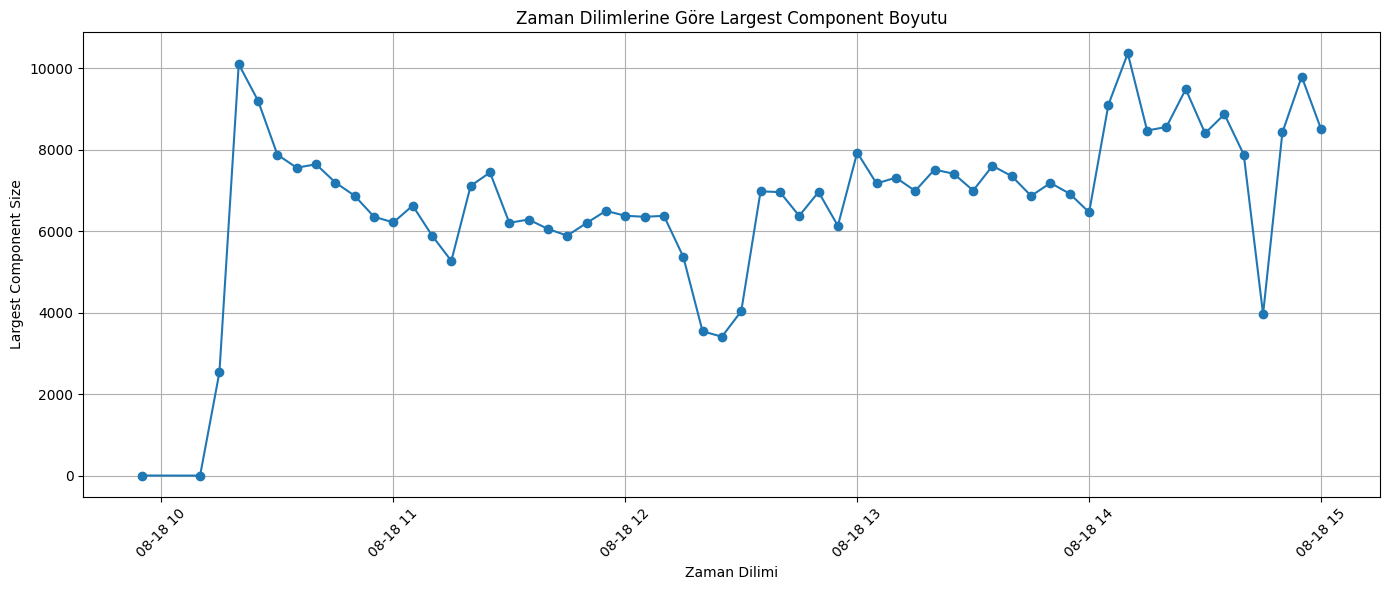

In [22]:
# zaman dilimlerine göre en büyük bileşen boyutu
largest_component_sizes = []
time_labels = []

for time_window, group in df.groupby("time_window"):

    G_temp = nx.from_pandas_edgelist(
        group,
        source="src_ip",
        target="dst_ip"
    )

    if len(G_temp.nodes()) > 0: #graph boş değilse devam et
        largest_cc = max(nx.connected_components(G_temp), key=len) #en büyük bağlı bileşeni bul
        largest_component_sizes.append(len(largest_cc)) #en büyük bileşenin düğüm sayısını listeye ekle
    else:
        largest_component_sizes.append(0) #graph boşşa 0 ekle

    time_labels.append(time_window)

plt.figure(figsize=(14, 6))
plt.plot(time_labels, largest_component_sizes, marker="o")

plt.title("Zaman Dilimlerine Göre Largest Component Boyutu")
plt.xlabel("Zaman Dilimi")
plt.ylabel("Largest Component Size")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

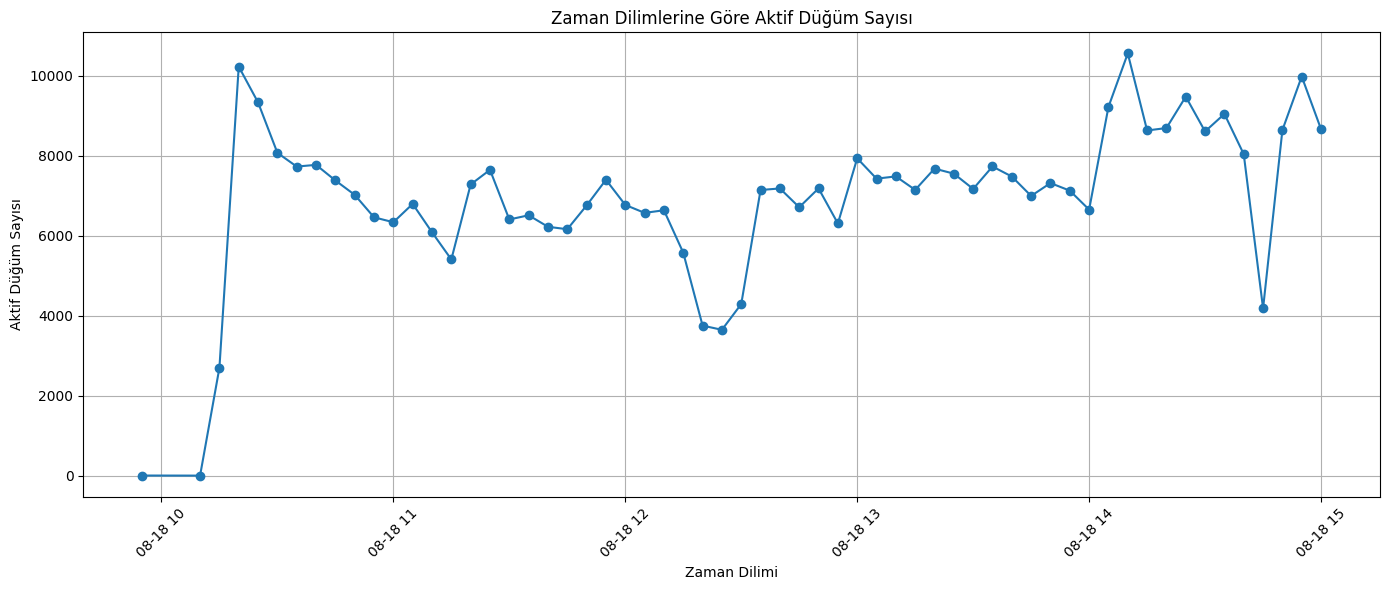

In [23]:
# zaman dilimlerine göre aktif düğüm sayısı
active_node_counts = []
time_labels = []

for time_window, group in df.groupby("time_window"):

    active_nodes = set(group["src_ip"]).union(set(group["dst_ip"]))

    active_node_counts.append(len(active_nodes))
    time_labels.append(time_window)

plt.figure(figsize=(14, 6))
plt.plot(time_labels, active_node_counts, marker="o")

plt.title("Zaman Dilimlerine Göre Aktif Düğüm Sayısı")
plt.xlabel("Zaman Dilimi")
plt.ylabel("Aktif Düğüm Sayısı")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# zaman dilimlerine göre botnet trafik oranı
df["is_botnet"] = df["label"].str.contains(
    "Botnet",
    case=False,
    na=False
)

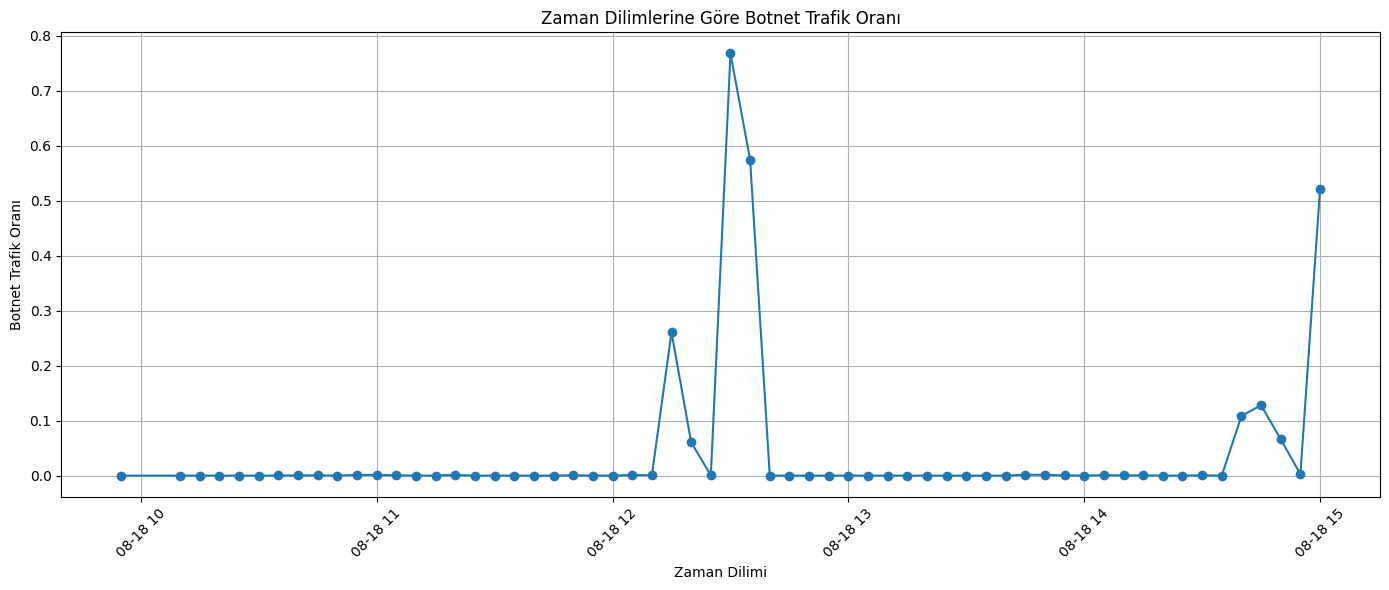

In [27]:
botnet_ratios = []
time_labels = []

for time_window, group in df.groupby("time_window"):

    total_count = len(group)
    botnet_count = group["is_botnet"].sum()

    ratio = botnet_count / total_count if total_count > 0 else 0

    botnet_ratios.append(ratio)
    time_labels.append(time_window)

plt.figure(figsize=(14, 6))
plt.plot(time_labels, botnet_ratios, marker="o")

plt.title("Zaman Dilimlerine Göre Botnet Trafik Oranı")
plt.xlabel("Zaman Dilimi")
plt.ylabel("Botnet Trafik Oranı")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
#kenar listesi oluşturma
edge_df = (
    df.groupby(["src_ip", "dst_ip"])  #ip çiftlerini grupla
    .agg(  #gruplanmış veri üzerinde işlem yap
        connection_count=("dst_ip", "count"), #aynı iki ip arasında kaç bağlantı var?
        total_packets=("total_packets", "sum"), #o bağlantıda kaç veri paketi taşınıyor?
        total_bytes=("total_bytes", "sum"),  #toplam veri boyutu
        avg_duration=("duration", "mean"), #ortalama bağlantı süresi
        botnet_ratio=("is_botnet", "mean")  #botnet oranı
    )
    .reset_index()
)

edge_df.head()

,src_ip,dst_ip,connection_count,total_packets,total_bytes,avg_duration,botnet_ratio
0,0.0.0.0,255.255.255.255,5,1639,543994,3404.900977,0.0
1,00:0b:ac:c4:e7:40,00:22:15:23:57:9e,1,2,120,0.014263,0.0
2,00:0b:ac:c5:cf:00,00:22:15:23:57:9e,1,2,120,0.008781,0.0
3,00:0c:29:97:a3:eb,ff:ff:ff:ff:ff:ff,4,4,240,0.000000,0.0
4,00:15:17:2c:e5:2d,ff:ff:ff:ff:ff:ff,5,2534,235697,3417.890674,0.0


In [23]:
# genel graph oluşturma
G = nx.DiGraph()

for _, row in edge_df.iterrows():
    G.add_edge(
        row["src_ip"],
        row["dst_ip"],
        weight=row["connection_count"],
        total_packets=row["total_packets"],
        total_bytes=row["total_bytes"],
        avg_duration=row["avg_duration"],
        botnet_ratio=row["botnet_ratio"]
    )

print("Düğüm sayısı:", G.number_of_nodes())
print("Kenar sayısı:", G.number_of_edges())

Düğüm sayısı: 197824
Kenar sayısı: 258027


In [20]:
# graph bilgileri
density = nx.density(G)

print("Ağ yoğunluğu:", density)
print("Yönlü ağ mı?:", nx.is_directed(G))

Ağ yoğunluğu: 6.593399491543745e-06
Yönlü ağ mı?: True


In [25]:
degrees = dict(G.degree())

degree_df = pd.DataFrame({
    "node": list(degrees.keys()),
    "degree": list(degrees.values())
}).sort_values("degree", ascending=False)

degree_df.head(10)

,node,degree
9,147.32.84.229,155068
103,147.32.84.59,26326
11,147.32.86.116,19962
100,147.32.84.118,7578
58,147.32.86.165,3191
3008,147.32.84.94,1515
150,147.32.85.218,1482
1280,147.32.85.26,1239
626,147.32.84.95,1230
579,147.32.84.68,1203


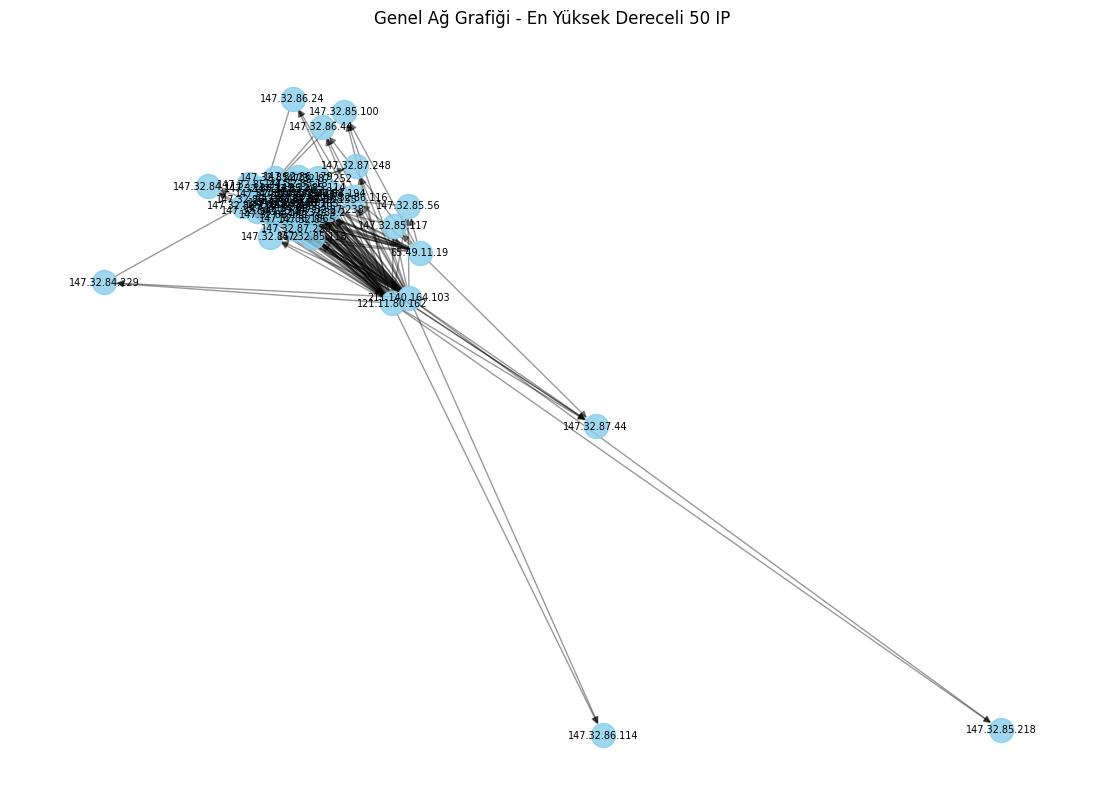

In [22]:
# ağ görselleştirilmesi
top_nodes = degree_df.head(50)["node"].tolist()

sub_G = G.subgraph(top_nodes).copy()  #ana grafın bu 50 düğümden oluşan kopyasını oluştur.

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(sub_G, seed=42, k=0.5)

nx.draw_networkx_nodes(
    sub_G,
    pos,
    node_size=300,
    node_color="skyblue",
    alpha=0.8
)

nx.draw_networkx_edges(
    sub_G,
    pos,
    arrows=True,
    alpha=0.4
)

nx.draw_networkx_labels(
    sub_G,
    pos,
    font_size=7
)

plt.title("Genel Ağ Grafiği - En Yüksek Dereceli 50 IP")
plt.axis("off")
plt.show()

Büyük veri setinde tüm ağı çizmek çok karmaşık olacağı için en yüksek dereceye sahip ilk 50 düğüm üzerinden alt graph çizilmiştir.

In [35]:
# komşuluk matrisi
center_node = degree_df.iloc[0]["node"] #degree entralitysi en yüksek olan düğümü seç.

successors = list(G.successors(center_node)) #bu IP’nin iletişim kurduğu hedef IP’ler
predecessors = list(G.predecessors(center_node)) #bu IP ile iletişim başlatan kaynak IP’ler

neighbors = list(set(successors + predecessors))

# merkez node + ilk 10 komşu
selected_nodes = [center_node] + neighbors[:7]

sub_G_adj = G.subgraph(selected_nodes).copy()

adj_matrix = nx.to_pandas_adjacency(
    sub_G_adj,
    nodelist=selected_nodes,
    weight="weight",
    dtype=int
)

adj_matrix

,147.32.84.229,173.171.28.197,64.202.147.248,109.96.234.244,93.193.34.153,83.228.58.59,69.120.218.162,87.62.236.163
147.32.84.229,0,1,1,0,0,0,0,0
173.171.28.197,0,0,0,0,0,0,0,0
64.202.147.248,0,0,0,0,0,0,0,0
109.96.234.244,1,0,0,0,0,0,0,0
93.193.34.153,1,0,0,0,0,0,0,0
83.228.58.59,1,0,0,0,0,0,0,0
69.120.218.162,2,0,0,0,0,0,0,0
87.62.236.163,2,0,0,0,0,0,0,0


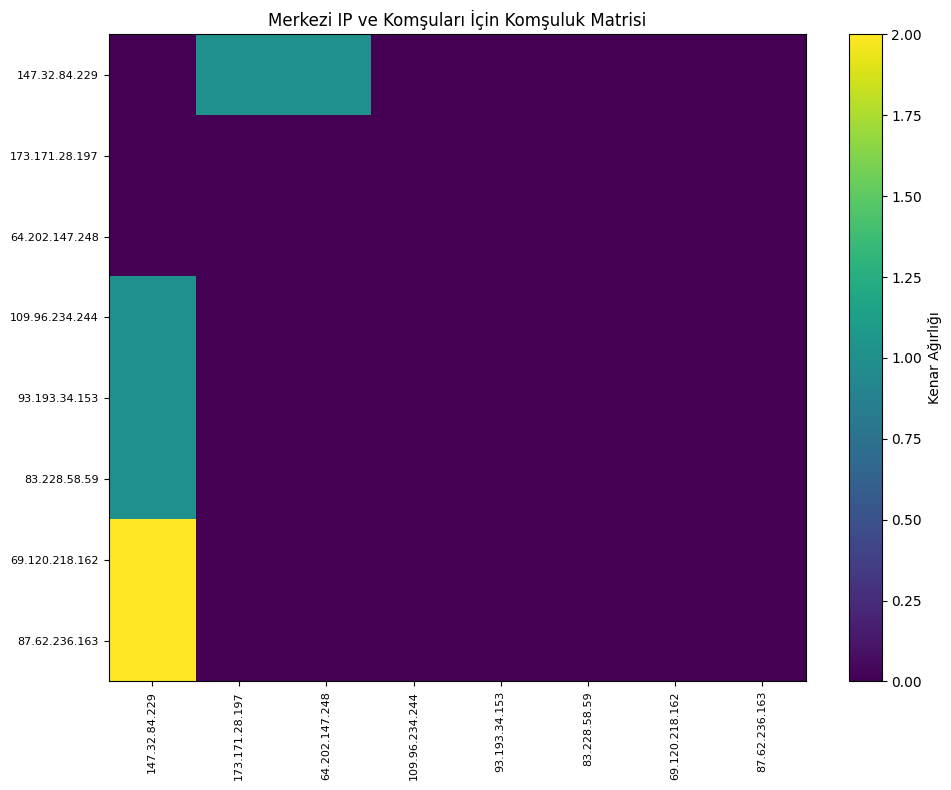

In [37]:
plt.figure(figsize=(10, 8))

plt.imshow(adj_matrix, aspect="auto")

plt.xticks(
    range(len(selected_nodes)),
    selected_nodes,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(selected_nodes)),
    selected_nodes,
    fontsize=8
)

plt.title("Merkezi IP ve Komşuları İçin Komşuluk Matrisi")
plt.colorbar(label="Kenar Ağırlığı")

plt.tight_layout()
plt.show()

In [36]:
# komşuluk listesi
adj_list = []

for node in selected_nodes:
    out_neighbors = list(G.successors(node))
    in_neighbors = list(G.predecessors(node))

    adj_list.append({
        "node": node,
        "out_neighbors": out_neighbors[:5],
        "in_neighbors": in_neighbors[:5],
        "out_degree": len(out_neighbors),
        "in_degree": len(in_neighbors)
    })

adj_list_df = pd.DataFrame(adj_list)
adj_list_df

,node,out_neighbors,in_neighbors,out_degree,in_degree
0,147.32.84.229,"[1.112.53.122, 1.160.113.144, 1.160.195.100, 1...","[1.112.121.154, 1.112.197.149, 1.112.217.186, ...",40180,114888
1,173.171.28.197,[],"[147.32.84.229, 147.32.84.59]",0,2
2,64.202.147.248,[],[147.32.84.229],0,1
3,109.96.234.244,[147.32.84.229],[],1,0
4,93.193.34.153,[147.32.84.229],[],1,0
5,83.228.58.59,[147.32.84.229],[],1,0
6,69.120.218.162,[147.32.84.229],[],1,0
7,87.62.236.163,[147.32.84.229],[],1,0


In [38]:
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()

print("Ortalama derece:", avg_degree)

Ortalama derece: 2.6086521352313166


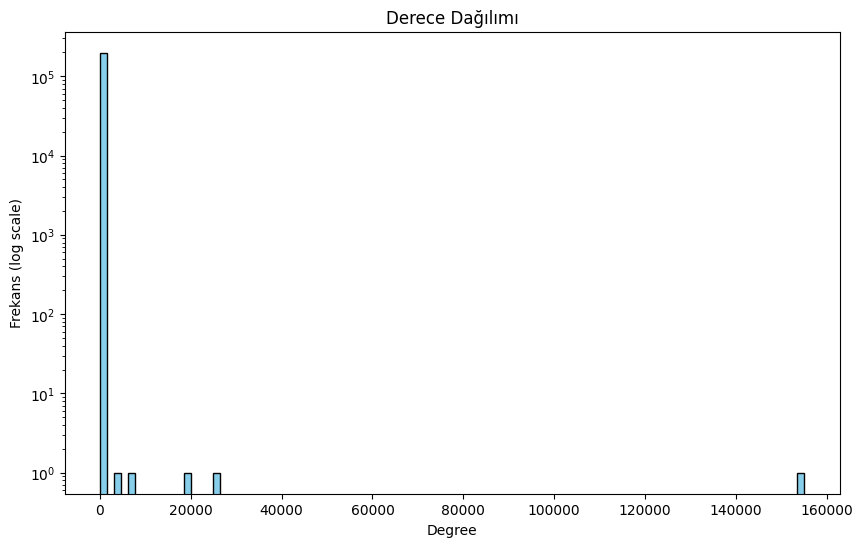

In [39]:
# derece dağılımı
degrees = [deg for node, deg in G.degree()]

plt.figure(figsize=(10,6))

plt.hist(
    degrees,
    bins=100,
    color="skyblue",
    edgecolor="black",
    log=True
)

plt.title("Derece Dağılımı")
plt.xlabel("Degree")
plt.ylabel("Frekans (log scale)")

plt.show()

In [43]:
# ağ çapı
largest_cc = max(nx.connected_components(G.to_undirected()), key=len)

largest_subgraph = G.subgraph(largest_cc).to_undirected()

sample_nodes = list(largest_subgraph.nodes())[:3000]

sample_graph = largest_subgraph.subgraph(sample_nodes)

largest_sample_cc = max(nx.connected_components(sample_graph), key=len)

connected_sample = sample_graph.subgraph(largest_sample_cc)

diameter_approx = nx.approximation.diameter(connected_sample)

print("Yaklaşık ağ çapı:", diameter_approx)

Yaklaşık ağ çapı: 10


In [45]:
# rastgele örnekleme ile hızlı clustering hesabı
sample_nodes = list(G.nodes())[:5000]

sample_graph = G.subgraph(sample_nodes).to_undirected()

clustering = nx.average_clustering(sample_graph)

print("Ortalama kümeleme katsayısı:", clustering)

Ortalama kümeleme katsayısı: 0.00010199358764771884


In [27]:
degree_centrality = nx.degree_centrality(G)

degree_df = pd.DataFrame({
    "node": list(degree_centrality.keys()),
    "degree_centrality": list(degree_centrality.values())
})

degree_df = degree_df.sort_values(
    "degree_centrality",
    ascending=False
)

degree_df.head(5)

,node,degree_centrality
9,147.32.84.229,0.783872
103,147.32.84.59,0.133079
11,147.32.86.116,0.100908
100,147.32.84.118,0.038307
58,147.32.86.165,0.016131


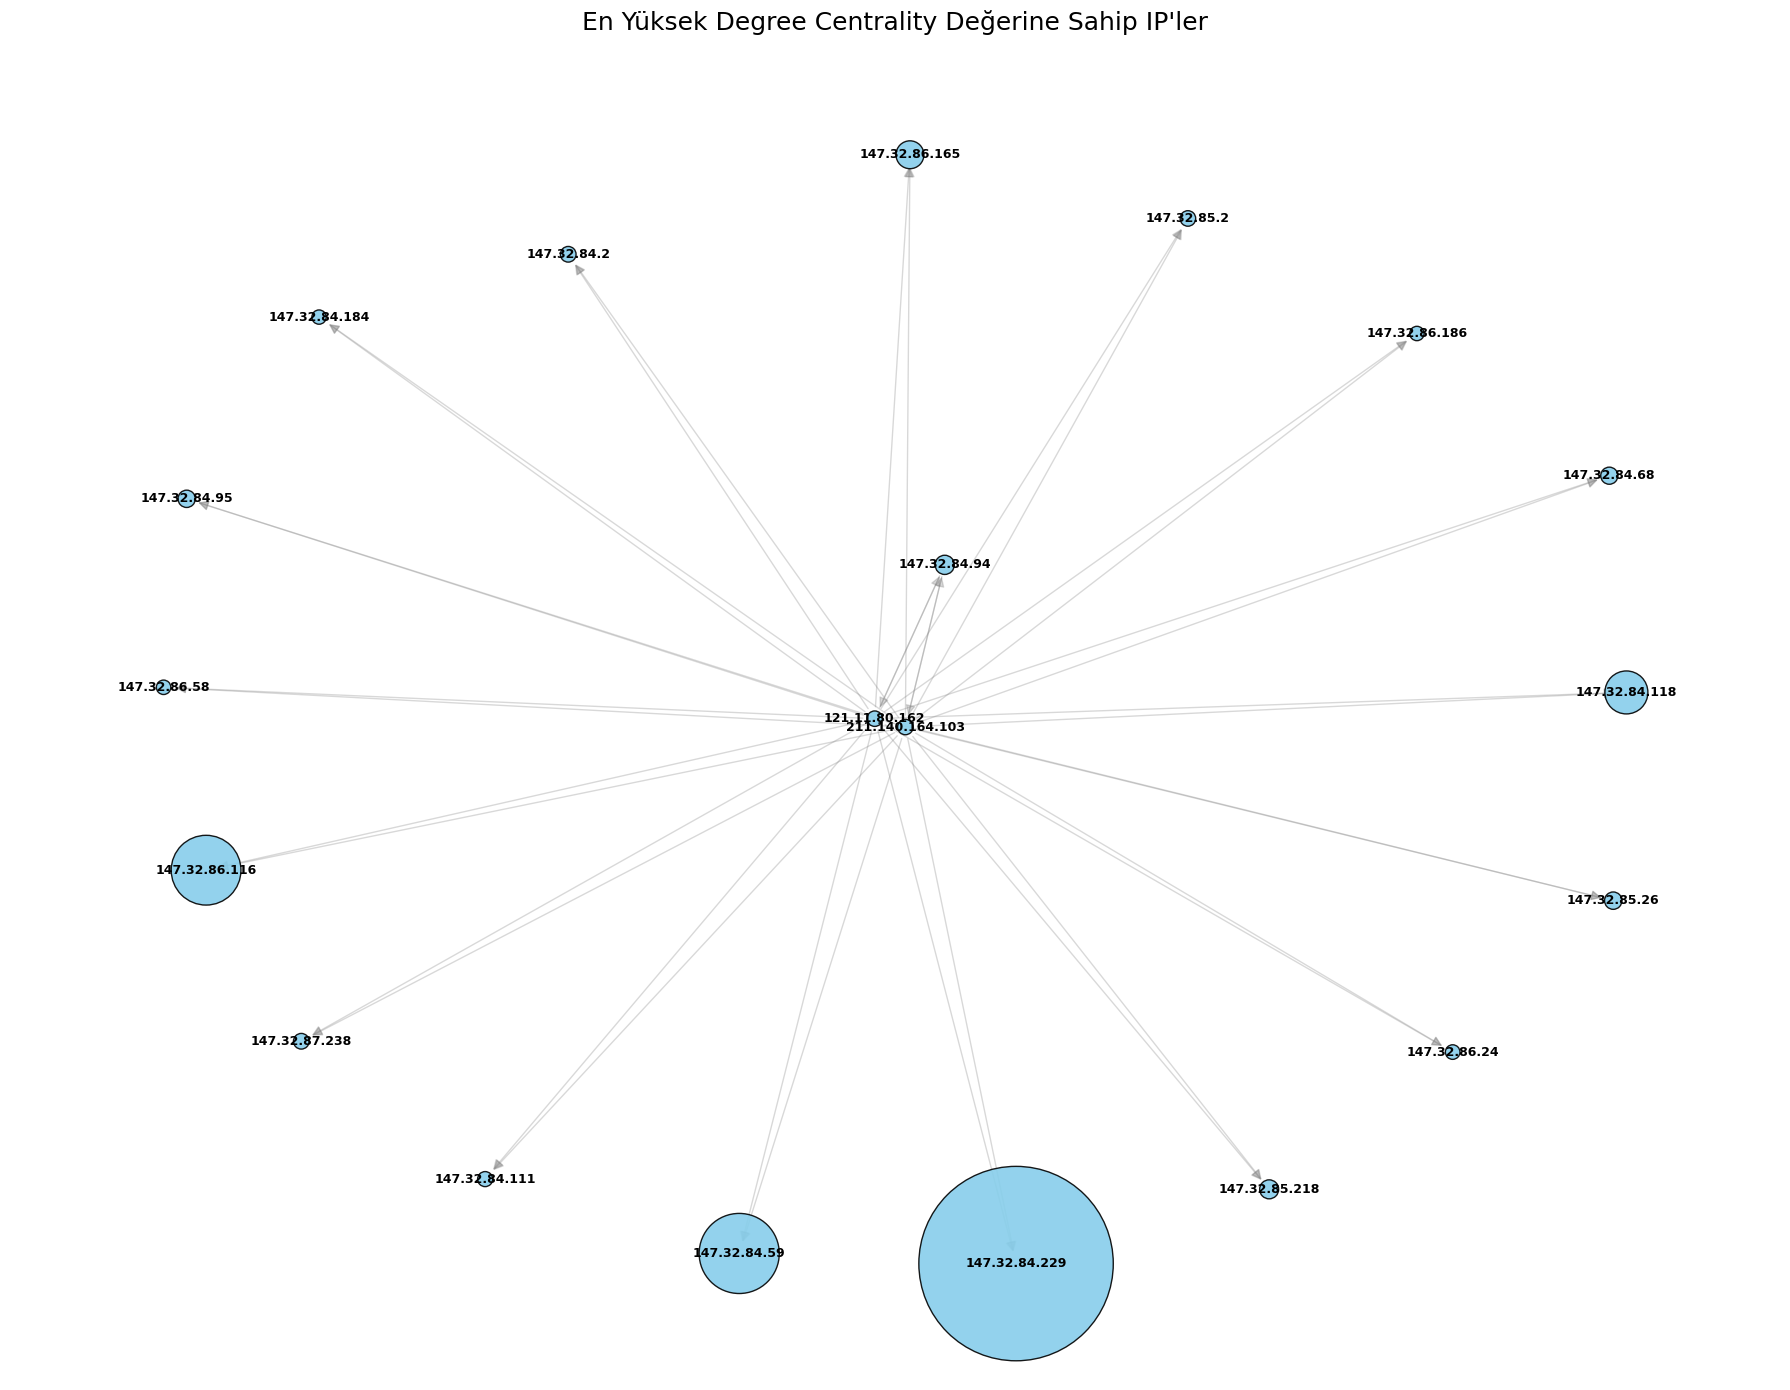

In [28]:
# En yüksek degree değerine sahip ilk 20 node
top_nodes = degree_df.head(20)["node"].tolist()

sub_G = G.subgraph(top_nodes).copy()

# Node boyutları
node_sizes = [
    degree_centrality[node] * 25000
    for node in sub_G.nodes()
]

# Daha büyük figür
plt.figure(figsize=(18, 14))

# Daha yayılmış layout
pos = nx.spring_layout(
    sub_G,
    k=1.5,
    iterations=100,
    seed=42
)

# Node çizimi
nx.draw_networkx_nodes(
    sub_G,
    pos,
    node_size=node_sizes,
    node_color="skyblue",
    edgecolors="black",
    linewidths=1,
    alpha=0.9
)

# Edge çizimi
nx.draw_networkx_edges(
    sub_G,
    pos,
    edge_color="gray",
    alpha=0.3,
    arrows=True,
    arrowsize=15
)

# Label çizimi
nx.draw_networkx_labels(
    sub_G,
    pos,
    font_size=9,
    font_weight="bold"
)

plt.title(
    "En Yüksek Degree Centrality Değerine Sahip IP'ler",
    fontsize=18
)

plt.axis("off")
plt.tight_layout()
plt.show()

### Degree Centrality 

Degree centrality analizi sonucunda, `147.32.84.229` IP adresinin yaklaşık **0.784** degree centrality değeri ile ağ içerisindeki en fazla bağlantıya sahip düğüm olduğu belirlenmiştir. Bu değerin diğer düğümlere göre oldukça yüksek olması, ilgili IP adresinin ağ içerisindeki birçok düğümle doğrudan iletişim kurduğunu göstermektedir.

İkinci sırada yer alan `147.32.84.59` düğümü yaklaşık **0.133** değeri ile daha sınırlı ancak yine de önemli bir bağlantı yoğunluğuna sahiptir. `147.32.86.116` ve `147.32.84.118` gibi düğümler de yüksek bağlantı sayılarıyla ağın aktif düğümleri arasında bulunmaktadır.

Graf görselleştirmesinde `147.32.84.229` düğümünün merkezde konumlandığı ve çok sayıda düğümle doğrudan bağlantı kurduğu açık şekilde görülmektedir. Bu yapı, ağın yıldız benzeri bir topolojiye sahip olduğunu ve belirli düğümlerin merkezileştiğini göstermektedir.

Degree centrality metriği doğrudan bağlantı sayısını ölçtüğü için, yüksek değere sahip düğümler ağ trafiğinde yoğun iletişim gerçekleştiren sistemler olarak değerlendirilebilir. Özellikle botnet veya anormal trafik analizlerinde bu tür düğümler kritik inceleme adaylarıdır.

Degree centrality analizi, ağ içerisindeki en aktif ve en fazla bağlantıya sahip düğümlerin belirlenmesini sağlamıştır.

In [29]:
# merkezilik çizimleri için fonksiyon
def draw_centrality_graph(graph, centrality_df, centrality_dict, title, color, size_multiplier=25000, top_n=20):
    
    top_nodes = centrality_df.head(top_n)["node"].tolist()
    sub_G = graph.subgraph(top_nodes).copy()

    node_sizes = [
        centrality_dict[node] * size_multiplier
        for node in sub_G.nodes()
    ]

    plt.figure(figsize=(18, 14))

    pos = nx.spring_layout(
        sub_G,
        k=1.5,
        iterations=100,
        seed=42
    )

    nx.draw_networkx_nodes(
        sub_G,
        pos,
        node_size=node_sizes,
        node_color=color,
        edgecolors="black",
        linewidths=1,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        sub_G,
        pos,
        edge_color="gray",
        alpha=0.3,
        arrows=True,
        arrowsize=15
    )

    nx.draw_networkx_labels(
        sub_G,
        pos,
        font_size=9,
        font_weight="bold"
    )

    plt.title(title, fontsize=18)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [32]:
# Yaklaşık betweenness centrality
betweenness = nx.betweenness_centrality(
    G,
    k=500,        # rastgele 500 node örnekler
    seed=42,
    normalized=True
)

betweenness_df = pd.DataFrame({
    "node": list(betweenness.keys()),
    "betweenness": list(betweenness.values())
}).sort_values("betweenness", ascending=False)

betweenness_df.head(5)

,node,betweenness
9,147.32.84.229,0.248204
103,147.32.84.59,0.072636
11,147.32.86.116,0.029673
100,147.32.84.118,0.019934
31918,147.32.80.9,0.014240


Veri setindeki düğüm sayısı yüksek olduğu için betweenness centrality değeri yaklaşık hesaplama yöntemiyle elde edilmiştir. Bu yöntem, tüm düğümler yerine rastgele seçilen düğüm örnekleri üzerinden köprü rolündeki IP adreslerini belirlemeyi amaçlamaktadır.

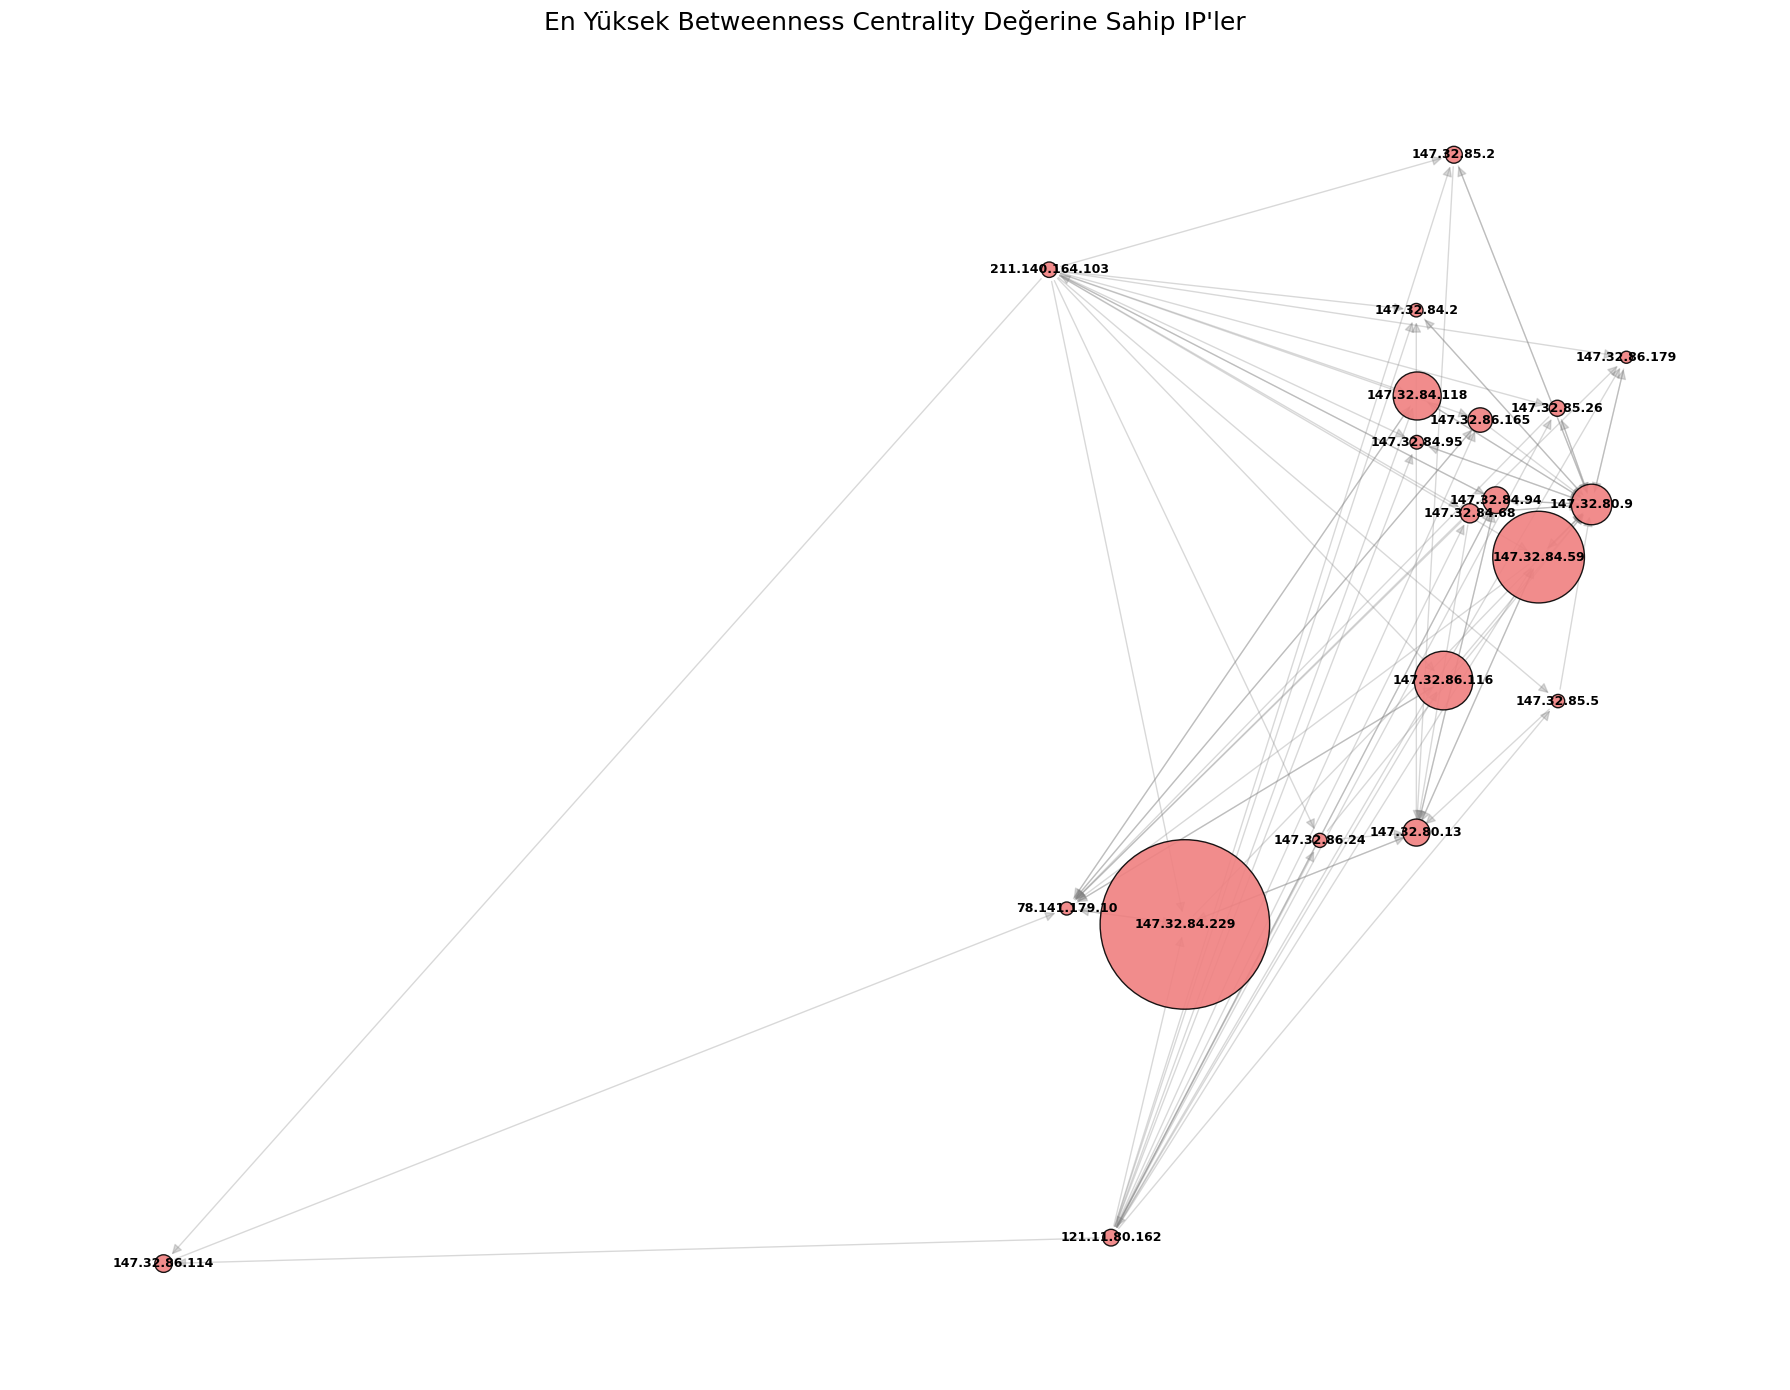

In [33]:
draw_centrality_graph(
    G,
    betweenness_df,
    betweenness,
    "En Yüksek Betweenness Centrality Değerine Sahip IP'ler",
    "lightcoral",
    60000
)

### Betweenness Centrality 

Betweenness centrality analizi sonucunda, ağ içerisindeki en kritik aracılık rolüne sahip düğümlerin belirli IP adreslerinde yoğunlaştığı görülmüştür. Özellikle `147.32.84.229` IP adresi yaklaşık **0.248** betweenness centrality değeri ile diğer tüm düğümlerden belirgin şekilde ayrılmaktadır. Bu durum, ilgili düğümün ağ içerisindeki birçok kısa yol üzerinde bulunduğunu ve farklı alt gruplar arasında köprü görevi üstlendiğini göstermektedir.

İkinci en yüksek değere sahip `147.32.84.59` düğümü ise yaklaşık **0.073** değeriyle ağda önemli ancak daha sınırlı bir aracılık etkisine sahiptir. Diğer düğümlerin değerleri incelendiğinde, ağın büyük ölçüde birkaç kritik düğüm etrafında şekillendiği anlaşılmaktadır.

Graf görselleştirmesinde de büyük boyutlu düğümlerin ağın merkezinde konumlandığı ve çok sayıda bağlantıyı birbirine bağladığı görülmektedir. Özellikle `147.32.84.229` düğümü, farklı kümeler arasındaki veri akışını sağlayan temel geçiş noktası gibi davranmaktadır. Bu tür yüksek betweenness değerine sahip düğümler, olası botnet kontrol noktaları veya ağ trafiğini yönlendiren kritik sistemler açısından önemli adaylar olarak değerlendirilebilir.

Betweenness centrality analizi ağ içerisindeki kritik geçiş noktalarını başarılı şekilde ortaya çıkarmış ve ağın merkezi iletişim yapısının belirli düğümler etrafında toplandığını göstermiştir.

In [34]:
# closness centrality - en yüksek degree node'larından alt graph oluştur
important_nodes = degree_df.head(500)["node"].tolist()

G_small = G.subgraph(important_nodes).copy()

closeness = nx.closeness_centrality(G_small)

closeness_df = pd.DataFrame({
    "node": list(closeness.keys()),
    "closeness": list(closeness.values())
}).sort_values("closeness", ascending=False)

closeness_df.head(5)

,node,closeness
347,147.32.80.9,0.519170
165,147.32.84.59,0.426575
362,147.32.80.7,0.382788
378,209.85.148.99,0.382366
478,74.125.232.206,0.381105


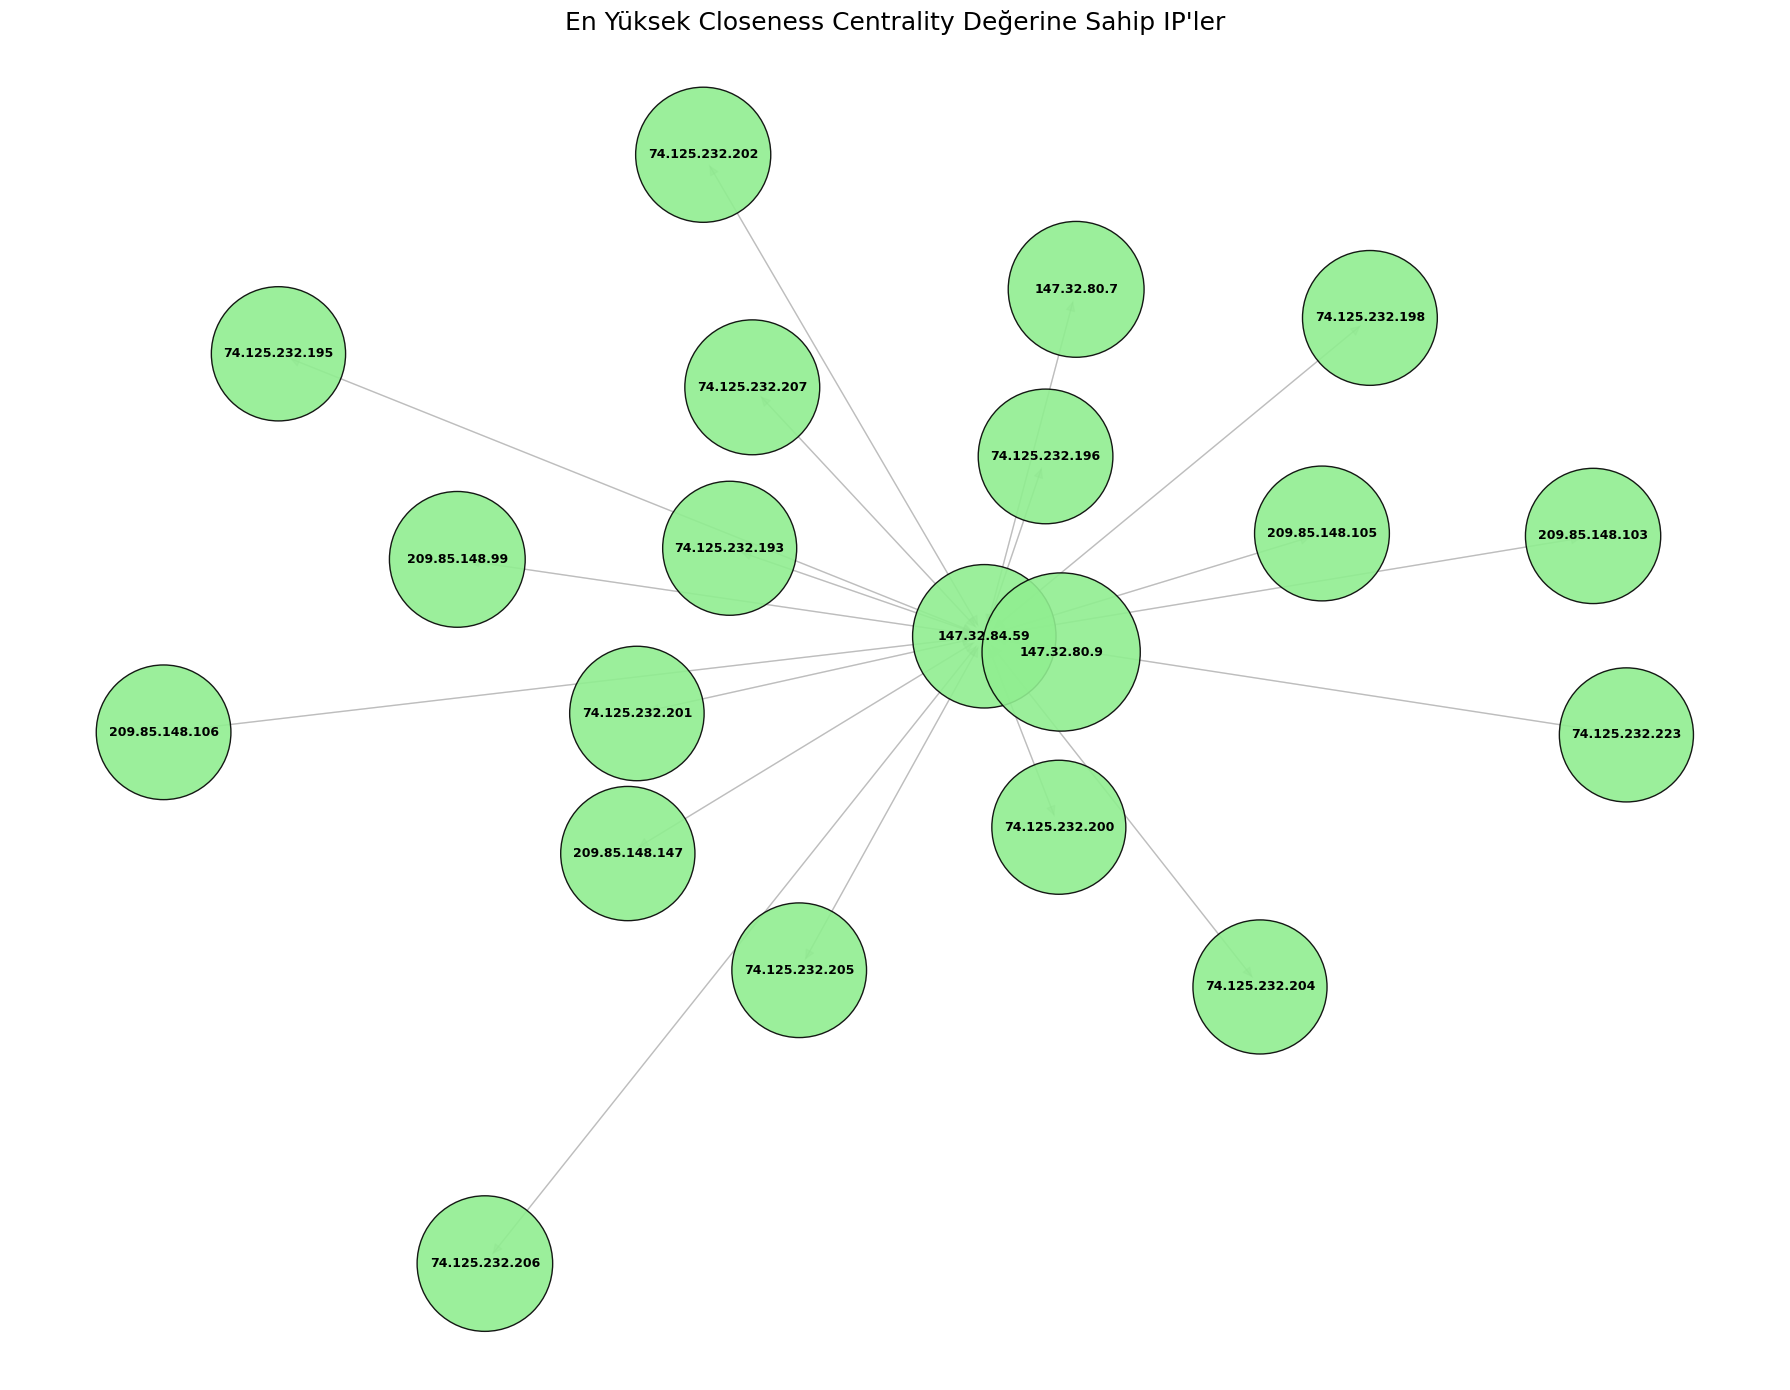

In [35]:
draw_centrality_graph(
    G_small,
    closeness_df,
    closeness,
    "En Yüksek Closeness Centrality Değerine Sahip IP'ler",
    "lightgreen",
    25000
)

### Closeness Centrality 

Closeness centrality analizi sonucunda, `147.32.80.9` IP adresinin yaklaşık **0.519** closeness değeri ile ağ içerisindeki diğer düğümlere en kısa ortalama uzaklığa sahip düğüm olduğu görülmüştür. Bu durum, ilgili düğümün ağ içerisinde bilgiye veya trafiğe hızlı erişim sağlayabilen merkezi bir konumda bulunduğunu göstermektedir.

Benzer şekilde `147.32.84.59` ve `147.32.80.7` düğümleri de yüksek closeness değerleri ile ağın merkezine yakın konumlanan önemli düğümler arasında yer almaktadır. Görselleştirme incelendiğinde, yüksek closeness değerine sahip düğümlerin ağın merkezinde toplandığı ve çevredeki birçok düğümle kısa yollar üzerinden bağlantı kurduğu görülmektedir.

Closeness centrality analizi, ağ içerisindeki hızlı erişim sağlayan merkezi düğümlerin belirlenmesinde etkili olmuştur.

In [36]:
# Eigenvector Centrality - önemli node'lardan oluşan alt graph üzerinde hesaplama

eigenvector = nx.eigenvector_centrality(
    G_small,
    max_iter=1000,
    tol=1e-06
)

eigenvector_df = pd.DataFrame({
    "node": list(eigenvector.keys()),
    "eigenvector_centrality": list(eigenvector.values())
}).sort_values("eigenvector_centrality", ascending=False)

eigenvector_df.head(5)

,node,eigenvector_centrality
165,147.32.84.59,0.352563
347,147.32.80.9,0.147431
378,209.85.148.99,0.112828
151,147.32.86.135,0.112240
478,74.125.232.206,0.111639


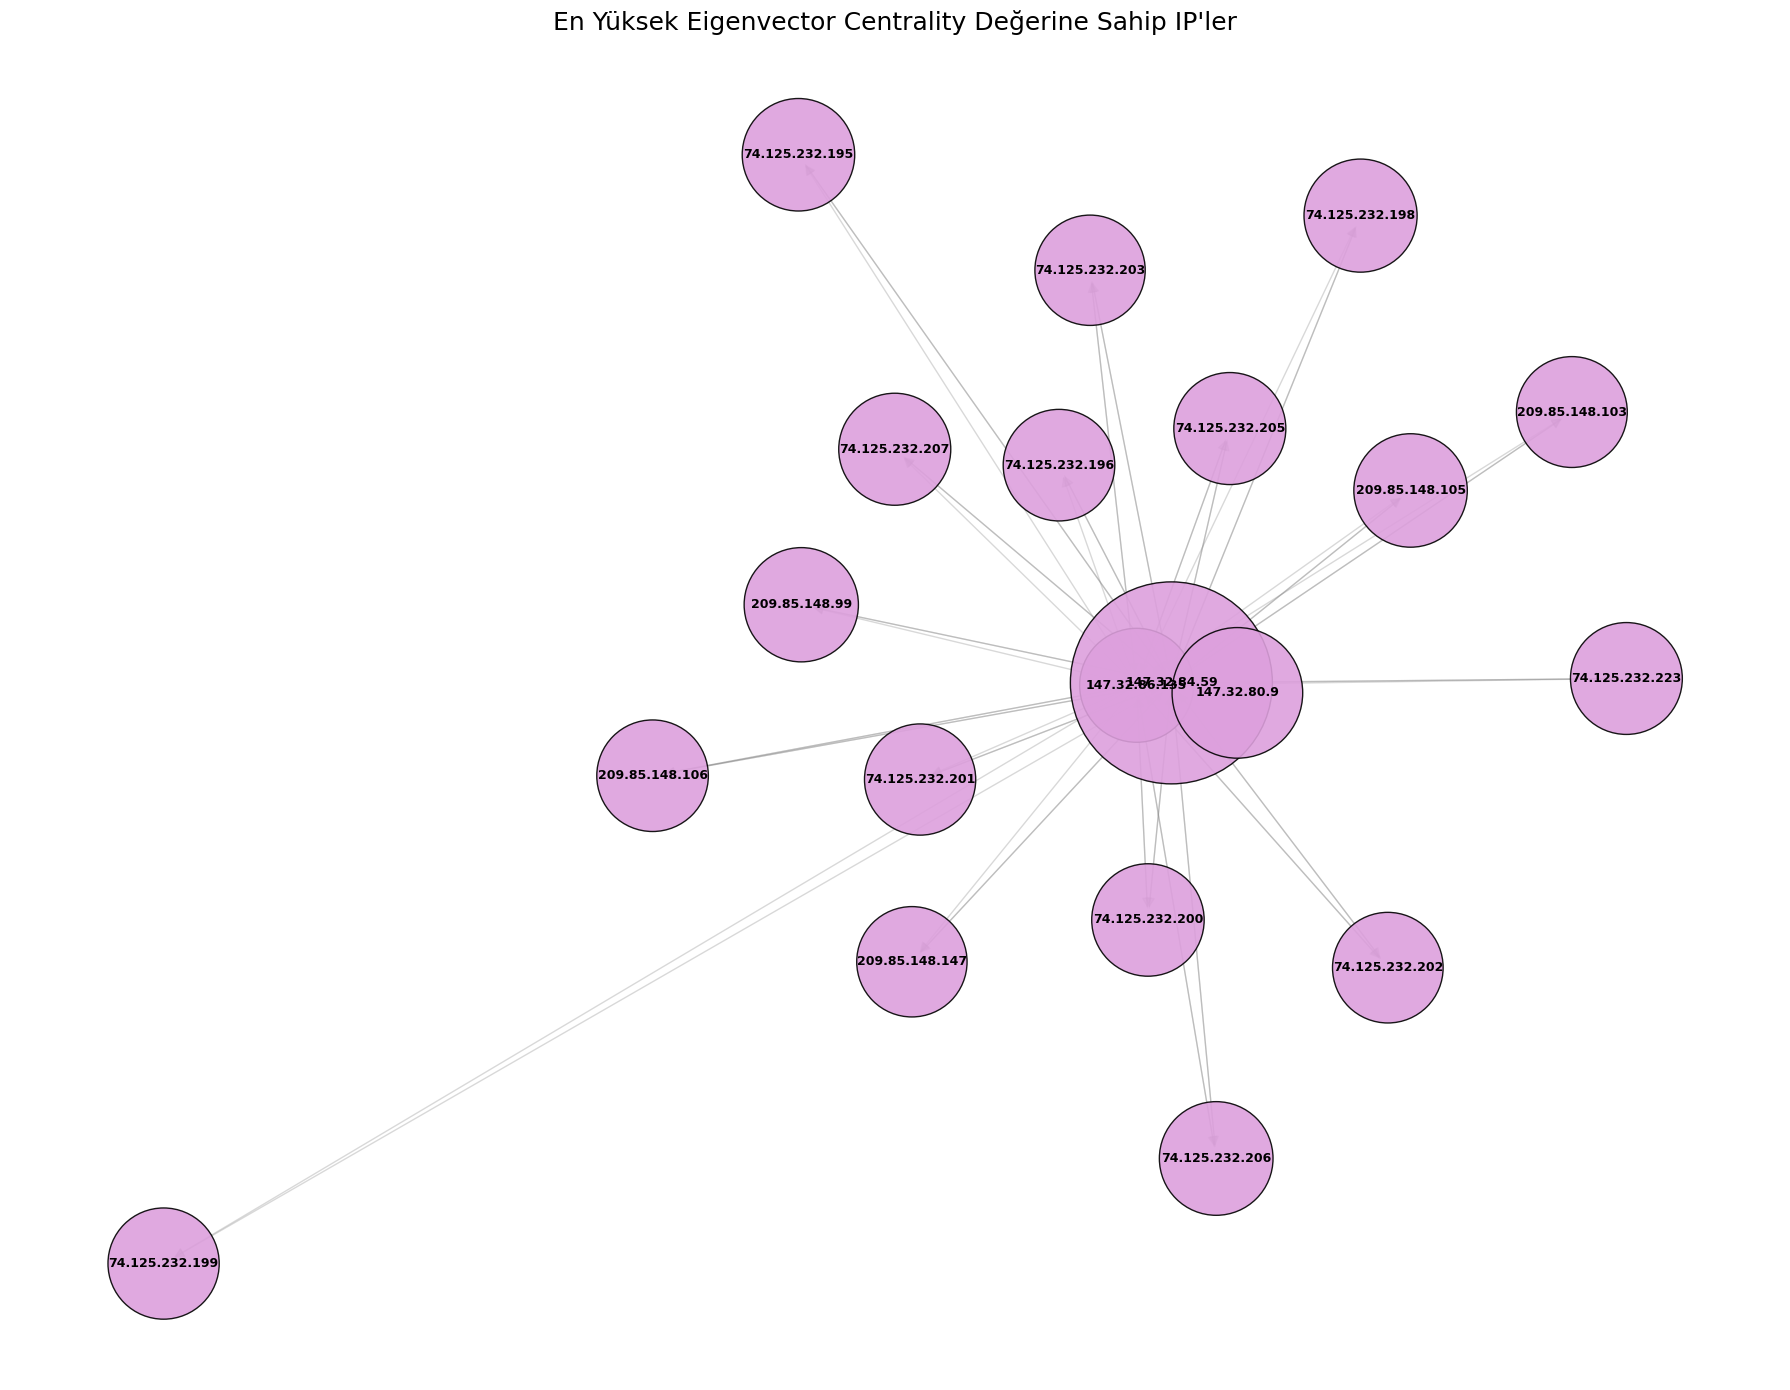

In [37]:
draw_centrality_graph(
    G_small,
    eigenvector_df,
    eigenvector,
    "En Yüksek Eigenvector Centrality Değerine Sahip IP'ler",
    "plum",
    60000
)

### Eigenvector Centrality 
Eigenvector centrality analizi sonucunda, `147.32.84.59` IP adresinin yaklaşık **0.353** değeri ile ağ içerisindeki en etkili düğüm olduğu belirlenmiştir. Eigenvector centrality metriği yalnızca bağlantı sayısını değil, bağlantı kurulan düğümlerin önemini de dikkate aldığı için bu sonuç, ilgili düğümün güçlü ve etkili düğümlerle bağlantılı olduğunu göstermektedir.

İkinci sırada yer alan `147.32.80.9` düğümü ise yaklaşık **0.147** değeri ile yine ağın önemli merkezlerinden biri olarak öne çıkmaktadır. Ayrıca `209.85.148.99`, `147.32.86.135` ve `74.125.232.206` gibi düğümlerin de yüksek eigenvector değerlerine sahip olması, bu düğümlerin ağ içerisindeki etkili iletişim yapısına dahil olduğunu göstermektedir.

Graf yapısında büyük düğümlerin ağın merkezinde yoğunlaştığı ve birçok önemli düğümle doğrudan bağlantılı olduğu görülmektedir. Bu durum, bazı IP adreslerinin ağ içerisindeki etki gücünün diğer düğümlere göre çok daha yüksek olduğunu ortaya koymaktadır.

Eigenvector centrality analizi, ağ içerisindeki yalnızca aktif değil aynı zamanda etkili bağlantılar kuran kritik düğümlerin belirlenmesini sağlamıştır.

In [38]:
# pagerank analizi
pagerank = nx.pagerank(G, weight="weight")

pagerank_df = pd.DataFrame({
    "node": list(pagerank.keys()),
    "pagerank": list(pagerank.values())
}).sort_values("pagerank", ascending=False)

pagerank_df.head(5)

,node,pagerank
9,147.32.84.229,0.229347
11,147.32.86.116,0.023936
31918,147.32.80.9,0.020663
103,147.32.84.59,0.019296
100,147.32.84.118,0.007309


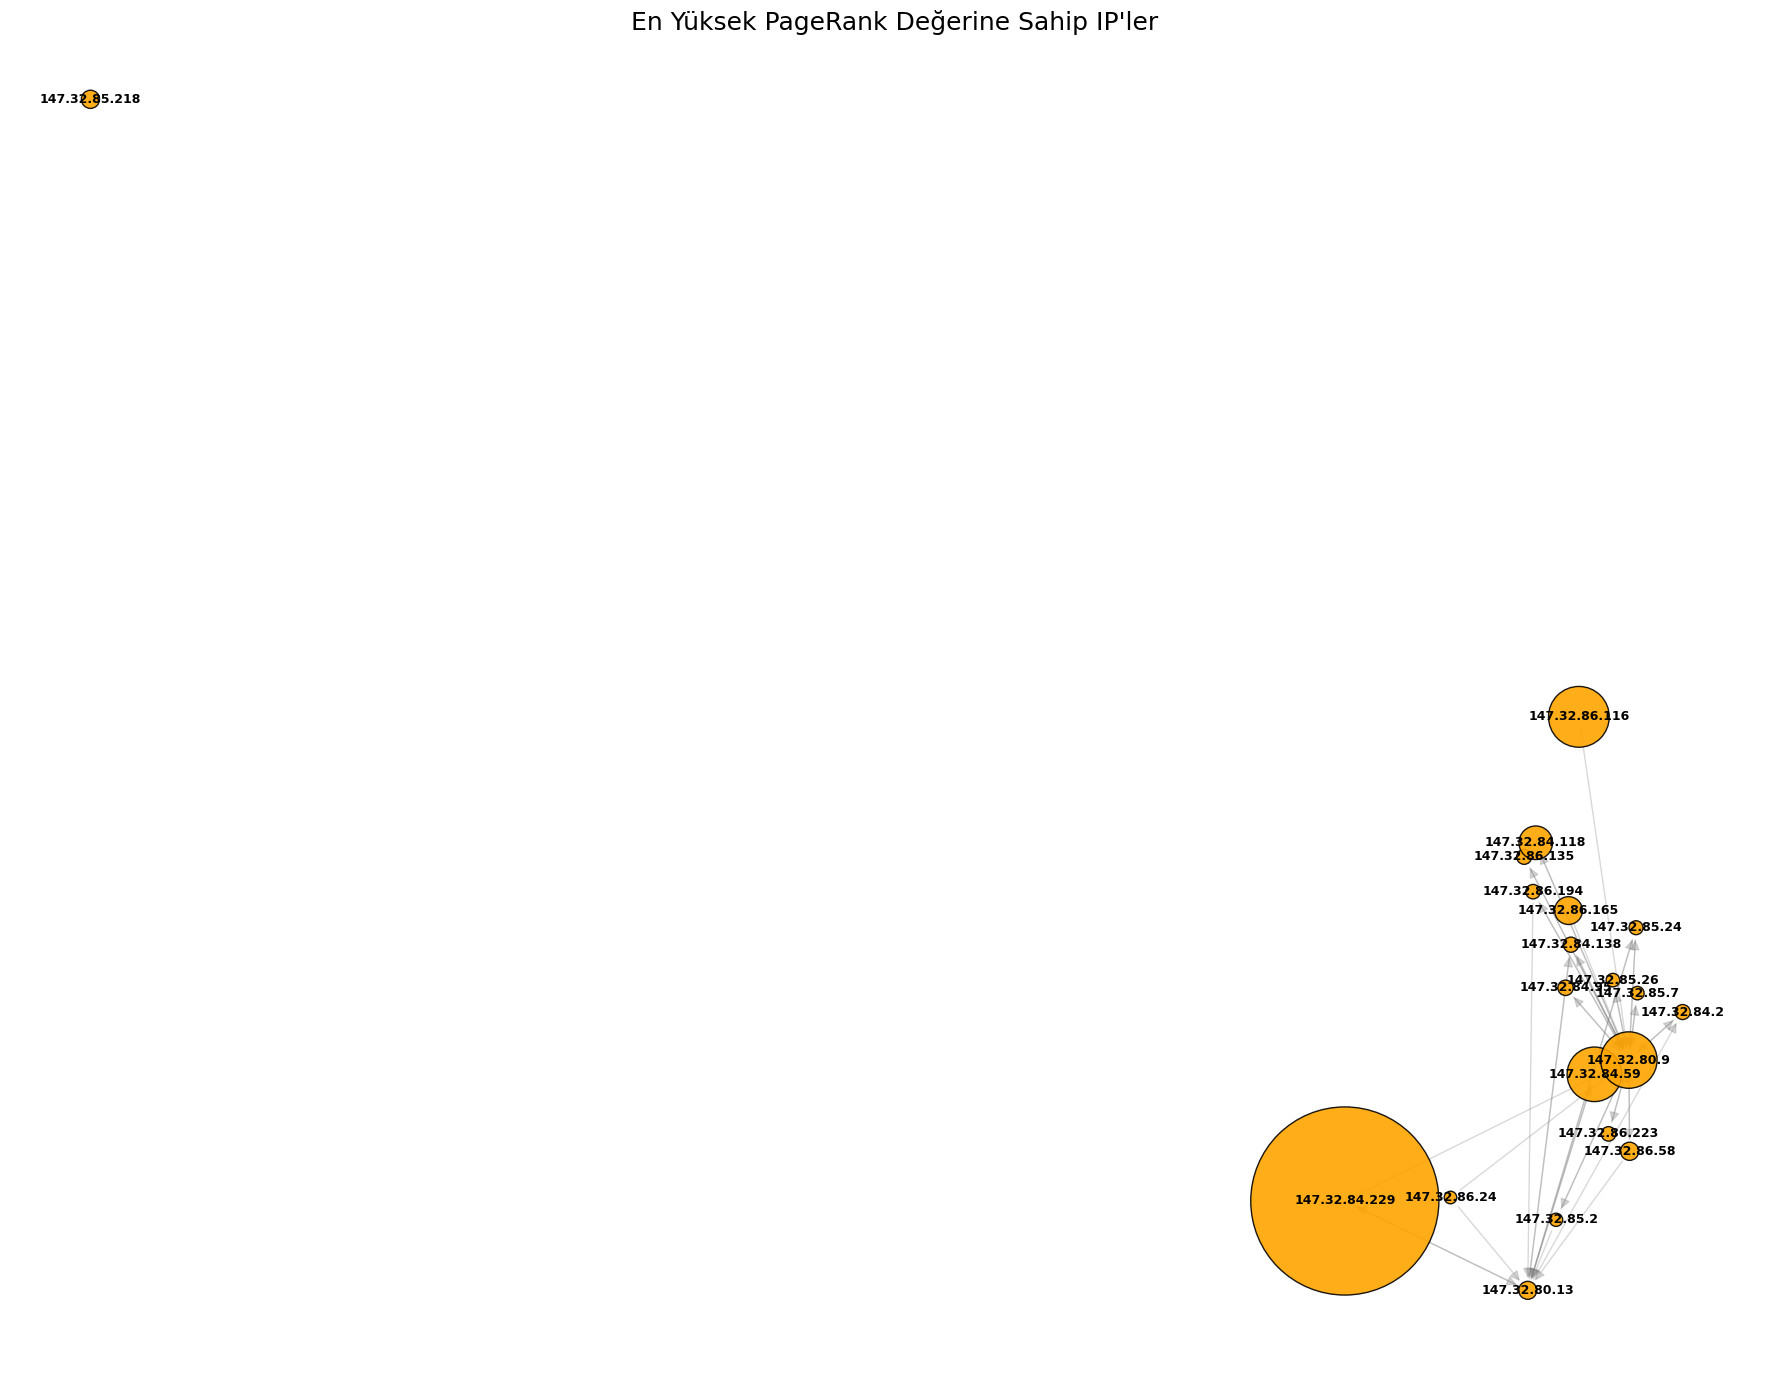

In [39]:
draw_centrality_graph(
    G,
    pagerank_df,
    pagerank,
    "En Yüksek PageRank Değerine Sahip IP'ler",
    "orange",
    80000
)

### PageRank Analizi

PageRank analizi sonucunda, `147.32.84.229` IP adresinin yaklaşık **0.229** değeri ile ağ içerisindeki en önemli düğüm olduğu görülmüştür. Bu değerin diğer düğümlere kıyasla oldukça yüksek olması, ilgili düğümün ağ içerisindeki bağlantılar tarafından yoğun şekilde referans alındığını göstermektedir.

`147.32.86.116`, `147.32.80.9` ve `147.32.84.59` düğümleri de yüksek PageRank değerlerine sahip olup ağ içerisinde önemli konumlarda yer almaktadır. Ancak görselleştirme incelendiğinde, `147.32.84.229` düğümünün belirgin şekilde baskın olduğu ve ağın büyük bölümünün bu düğüm etrafında toplandığı görülmektedir.

PageRank metriği, bağlantıların önemini ağırlıklı olarak değerlendirdiği için bu sonuçlar ilgili düğümlerin yalnızca fazla bağlantıya sahip olmadığını, aynı zamanda önemli düğümler tarafından da desteklendiğini göstermektedir. Özellikle yüksek PageRank değerine sahip IP adresleri, ağ trafiğinde kritik rol oynayan veya merkezi iletişim noktaları olarak çalışan sistemler olabilir.

PageRank analizi, ağ içerisindeki otorite niteliğindeki düğümlerin belirlenmesinde etkili olmuş ve ağ yapısındaki baskın düğümleri ortaya çıkarmıştır.

In [32]:
# merkezilik sonuçlarını birleştirme
centrality_df = degree_df.merge(betweenness_df, on="node", how="left")
centrality_df = centrality_df.merge(closeness_df, on="node", how="left")
centrality_df = centrality_df.merge(pagerank_df, on="node", how="left")

centrality_df.head(10)

,node,degree_centrality,betweenness,closeness,pagerank
0,147.32.84.229,0.783872,0.248204,0.282185,0.229347
1,147.32.84.59,0.133079,0.072636,0.426575,0.019296
2,147.32.86.116,0.100908,0.029673,0.289729,0.023936
3,147.32.84.118,0.038307,0.019934,0.348899,0.007309
4,147.32.86.165,0.016131,0.005154,0.259197,0.005018
5,147.32.84.94,0.007658,0.006153,0.334109,0.000874
6,147.32.85.218,0.007492,0.000000,0.194897,0.002138
7,147.32.85.26,0.006263,0.002220,0.342017,0.001194
8,147.32.84.95,0.006218,0.001608,0.338017,0.001534
9,147.32.84.68,0.006081,0.003183,0.336378,0.000392


## Merkezilik Analizi Yorumu

Bu aşamada ağ içerisindeki önemli IP adresleri farklı merkezilik ölçütleriyle incelenmiştir.

- Degree centrality, en fazla bağlantıya sahip IP adreslerini göstermektedir.
- Betweenness centrality, ağda köprü görevi gören IP adreslerini ortaya çıkarmaktadır.
- Closeness centrality, ağdaki diğer düğümlere daha kısa yoldan erişebilen IP adreslerini göstermektedir.
- PageRank ise yalnızca bağlantı sayısını değil, bağlantı kurulan düğümlerin önemini de dikkate almaktadır.

Bu nedenle aynı IP adresinin birden fazla merkezilik ölçütünde üst sıralarda yer alması, o düğümün ağ yapısı açısından kritik olduğunu göstermektedir.

In [16]:
# zaman dilimi için graph oluşturma
def create_graph_for_time_window(data, time_window):
    window_df = data[data["time_window"] == time_window].copy()
    
    edge_window_df = (
        window_df.groupby(["src_ip", "dst_ip"])
        .agg(
            connection_count=("dst_ip", "count"),
            total_packets=("total_packets", "sum"),
            total_bytes=("total_bytes", "sum"),
            avg_duration=("duration", "mean"),
            botnet_ratio=("is_botnet", "mean")
        )
        .reset_index()
    )
    
    G_window = nx.DiGraph()
    
    for _, row in edge_window_df.iterrows():
        G_window.add_edge(
            row["src_ip"],
            row["dst_ip"],
            weight=row["connection_count"],
            total_packets=row["total_packets"],
            total_bytes=row["total_bytes"],
            avg_duration=row["avg_duration"],
            botnet_ratio=row["botnet_ratio"]
        )
    
    return G_window

In [19]:
# zamansal ağ analizi
temporal_summary = []

for window in sorted(df["time_window"].unique()):
    G_temp = create_graph_for_time_window(df, window)
    
    node_count = G_temp.number_of_nodes()
    edge_count = G_temp.number_of_edges()
    
    avg_degree = np.mean([d for _, d in G_temp.degree()]) if node_count > 0 else 0
    density = nx.density(G_temp) if node_count > 1 else 0
    
    temporal_summary.append({
        "time_window": window,
        "node_count": node_count,
        "edge_count": edge_count,
        "density": density,
        "avg_degree": avg_degree
    })

temporal_summary_df = pd.DataFrame(temporal_summary)

temporal_summary_df.head()

,time_window,node_count,edge_count,density,avg_degree
0,2011-08-18 09:55:00,4,3,0.250000,1.500000
1,2011-08-18 10:10:00,2,1,0.500000,1.000000
2,2011-08-18 10:15:00,2697,2962,0.000407,2.196515
3,2011-08-18 10:20:00,10233,11338,0.000108,2.215968
4,2011-08-18 10:25:00,9337,10117,0.000116,2.167077


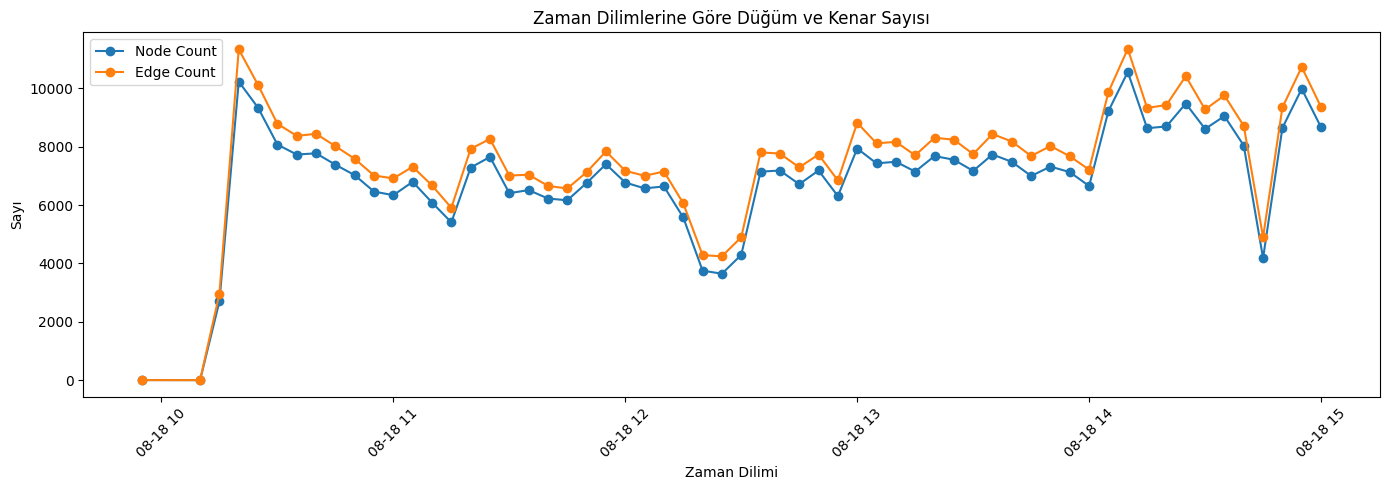

In [35]:
#zamanla node ve edge değişimi 
plt.figure(figsize=(14, 5))

plt.plot(
    temporal_summary_df["time_window"],
    temporal_summary_df["node_count"],
    marker="o",
    label="Node Count"
)

plt.plot(
    temporal_summary_df["time_window"],
    temporal_summary_df["edge_count"],
    marker="o",
    label="Edge Count"
)

plt.title("Zaman Dilimlerine Göre Düğüm ve Kenar Sayısı")
plt.xlabel("Zaman Dilimi")
plt.ylabel("Sayı")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Zaman pencerelerine göre oluşturulan ağ yapıları incelendiğinde düğüm ve kenar sayılarının zaman içerisinde değiştiği gözlemlenmiştir.

Özellikle bazı zaman dilimlerinde ağ boyutunun ani şekilde arttığı görülmektedir. Bu durum ilgili zaman aralıklarında ağ trafiğinin yoğunlaştığını göstermektedir. Ağdaki düğüm sayısının artması, daha fazla IP adresinin iletişime geçtiğini; kenar sayısının artması ise IP adresleri arasındaki bağlantı miktarının yükseldiğini ifade etmektedir.

Grafikte düğüm ve kenar sayılarının genel olarak benzer eğilim göstermesi, ağ büyüklüğü ile bağlantı yoğunluğu arasında doğrudan bir ilişki olduğunu göstermektedir.

Bazı zaman dilimlerinde gözlemlenen ani düşüşler ise:
- trafiğin geçici olarak azalması,
- belirli node’ların iletişimi kesmesi,
- veya botnet aktivitelerinin belirli aralıklarla gerçekleşmesi

gibi nedenlerden kaynaklanabilir.

Bu sonuçlar ağ yapısının statik değil, zamanla değişen dinamik bir yapı sergilediğini göstermektedir.

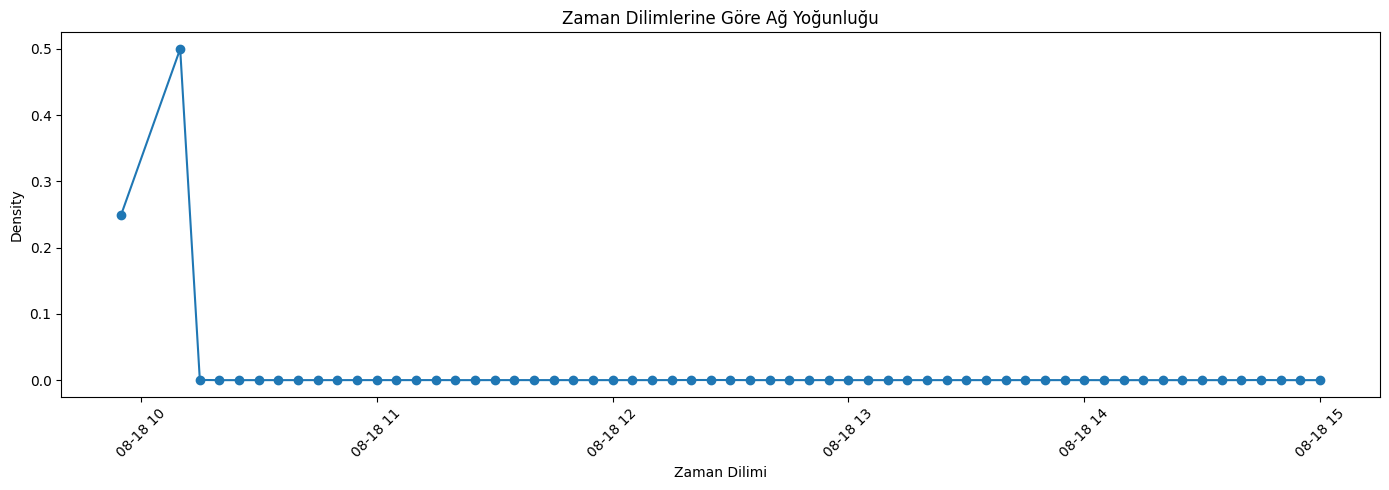

In [36]:
# zamanla density değişimi
plt.figure(figsize=(14, 5))

plt.plot(
    temporal_summary_df["time_window"],
    temporal_summary_df["density"],
    marker="o"
)

plt.title("Zaman Dilimlerine Göre Ağ Yoğunluğu")
plt.xlabel("Zaman Dilimi")
plt.ylabel("Density")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ağ yoğunluğu (density), ağ içerisindeki mevcut bağlantıların mümkün olan maksimum bağlantı sayısına oranını göstermektedir.

Grafik incelendiğinde ilk zaman dilimlerinde yoğunluk değerinin daha yüksek olduğu görülmektedir. Bunun temel nedeni bu zaman aralıklarında ağdaki düğüm sayısının oldukça düşük olmasıdır. Düğüm sayısı az olduğunda mevcut bağlantılar ağ yoğunluğunu daha yüksek göstermektedir.

Daha sonraki zaman dilimlerinde düğüm sayısının hızla artmasıyla birlikte yoğunluk değerinin oldukça düşük seviyelere indiği görülmektedir. Bu durum ağın genişlediğini ancak tüm düğümlerin birbirleriyle yoğun şekilde bağlantılı olmadığını göstermektedir.

Bu yapı gerçek ağ trafiği davranışı ile uyumludur. Büyük ölçekli ağlarda genellikle:
- çok sayıda düğüm bulunur,
- ancak her düğüm yalnızca sınırlı sayıda başka düğümle iletişim kurar.

Bu nedenle düşük yoğunluk değeri ağın seyrek (sparse) yapıda olduğunu göstermektedir.

In [37]:
# steath-like node tespiti
node_behavior_df = (
    df.groupby("src_ip")
    .agg(
        unique_targets=("dst_ip", "nunique"),
        connection_count=("dst_ip", "count"),
        total_packets=("total_packets", "sum"),
        total_bytes=("total_bytes", "sum"),
        active_windows=("time_window", "nunique"),
        botnet_ratio=("is_botnet", "mean")
    )
    .reset_index()
)

node_behavior_df["avg_packets_per_connection"] = (
    node_behavior_df["total_packets"] / node_behavior_df["connection_count"]
)

node_behavior_df["avg_bytes_per_connection"] = (
    node_behavior_df["total_bytes"] / node_behavior_df["connection_count"]
)

node_behavior_df.head()

,src_ip,unique_targets,connection_count,total_packets,total_bytes,active_windows,botnet_ratio,avg_packets_per_connection,avg_bytes_per_connection
0,0.0.0.0,1,5,1639,543994,5,0.0,327.8,108798.8
1,00:0b:ac:c4:e7:40,1,1,2,120,1,0.0,2.0,120.0
2,00:0b:ac:c5:cf:00,1,1,2,120,1,0.0,2.0,120.0
3,00:0c:29:97:a3:eb,1,4,4,240,4,0.0,1.0,60.0
4,00:15:17:2c:e5:2d,1,5,2534,235697,5,0.0,506.8,47139.4


## Node Davranış Özelliklerinin İncelenmesi

Bu aşamada her kaynak IP adresi için davranışsal ağ özellikleri çıkarılmıştır.

Hesaplanan özellikler:

- unique_targets → iletişim kurulan farklı hedef IP sayısı
- connection_count → toplam bağlantı sayısı
- total_packets → toplam paket miktarı
- total_bytes → toplam veri miktarı
- active_windows → aktif olduğu zaman dilimi sayısı
- avg_packets_per_connection → bağlantı başına ortalama paket miktarı
- avg_bytes_per_connection → bağlantı başına ortalama veri miktarı

Bu özellikler kullanılarak ağ içerisindeki normal davranış gösteren düğümler ile düşük hacimli fakat süreklilik gösteren şüpheli düğümler arasındaki farkların ortaya çıkarılması amaçlanmıştır.

Özellikle:
- çok sayıda farklı hedefe bağlanan,
- uzun süre aktif kalan,
- ancak bağlantı başına düşük veri üreten

IP adresleri stealth-like davranış adayı olarak değerlendirilebilir.

In [38]:
# steath-like skor oluşturma
# Eşik değerleri veri dağılımına göre belirliyoruz
target_threshold = node_behavior_df["unique_targets"].quantile(0.75)
window_threshold = node_behavior_df["active_windows"].quantile(0.75)
packet_threshold = node_behavior_df["avg_packets_per_connection"].quantile(0.25)
byte_threshold = node_behavior_df["avg_bytes_per_connection"].quantile(0.25)

node_behavior_df["is_stealth_like"] = (
    (node_behavior_df["unique_targets"] >= target_threshold) &
    (node_behavior_df["active_windows"] >= window_threshold) &
    (node_behavior_df["avg_packets_per_connection"] <= packet_threshold) &
    (node_behavior_df["avg_bytes_per_connection"] <= byte_threshold)
).astype(int)

stealth_nodes_df = node_behavior_df.sort_values(
    ["is_stealth_like", "unique_targets", "active_windows"],
    ascending=False
)

stealth_nodes_df.head(15)

,src_ip,unique_targets,connection_count,total_packets,total_bytes,active_windows,botnet_ratio,avg_packets_per_connection,avg_bytes_per_connection,is_stealth_like
26290,125.39.104.81,235,290,393,23580,21,0.0,1.355172,81.310345,1
148577,98.126.54.92,228,270,393,24188,56,0.0,1.455556,89.585185,1
25445,125.141.229.197,221,296,387,23812,58,0.0,1.307432,80.445946,1
35497,173.212.245.210,217,262,368,22638,34,0.0,1.404580,86.404580,1
10715,113.105.171.57,103,110,134,8700,49,0.0,1.218182,79.090909,1
10717,113.105.171.59,100,106,133,8616,48,0.0,1.254717,81.283019,1
10713,113.105.171.54,99,105,130,8430,49,0.0,1.238095,80.285714,1
92570,76.164.192.82,99,106,158,9726,16,0.0,1.490566,91.754717,1
10718,113.105.171.60,98,104,129,8364,51,0.0,1.240385,80.423077,1
10719,113.105.171.62,98,105,133,8610,49,0.0,1.266667,82.000000,1


## Stealth-like Node Tespiti Sonuçları

Stealth-like davranış analizi sonucunda bazı IP adreslerinin dikkat çekici özellikler gösterdiği görülmüştür.

Bu düğümler:
- çok sayıda farklı hedef IP ile iletişim kurmakta,
- birden fazla zaman penceresinde aktif kalmakta,
- ancak bağlantı başına oldukça düşük paket ve byte miktarı üretmektedir.

Bu davranış yapısı klasik yüksek hacimli saldırılardan farklıdır. Daha düşük görünürlükle çalışan ve ağ içerisinde uzun süre aktif kalmayı hedefleyen stealth-benzeri davranış örüntülerine işaret edebilir.

Özellikle düşük veri hacmine rağmen çok sayıda farklı hedefle iletişim kuran IP adresleri ağ açısından şüpheli davranış gösteren düğümler olarak değerlendirilmiştir.

In [39]:
# steath-like node sayısı
stealth_nodes_df["is_stealth_like"].value_counts()

is_stealth_like
0    145953
1      5303
Name: count, dtype: int64

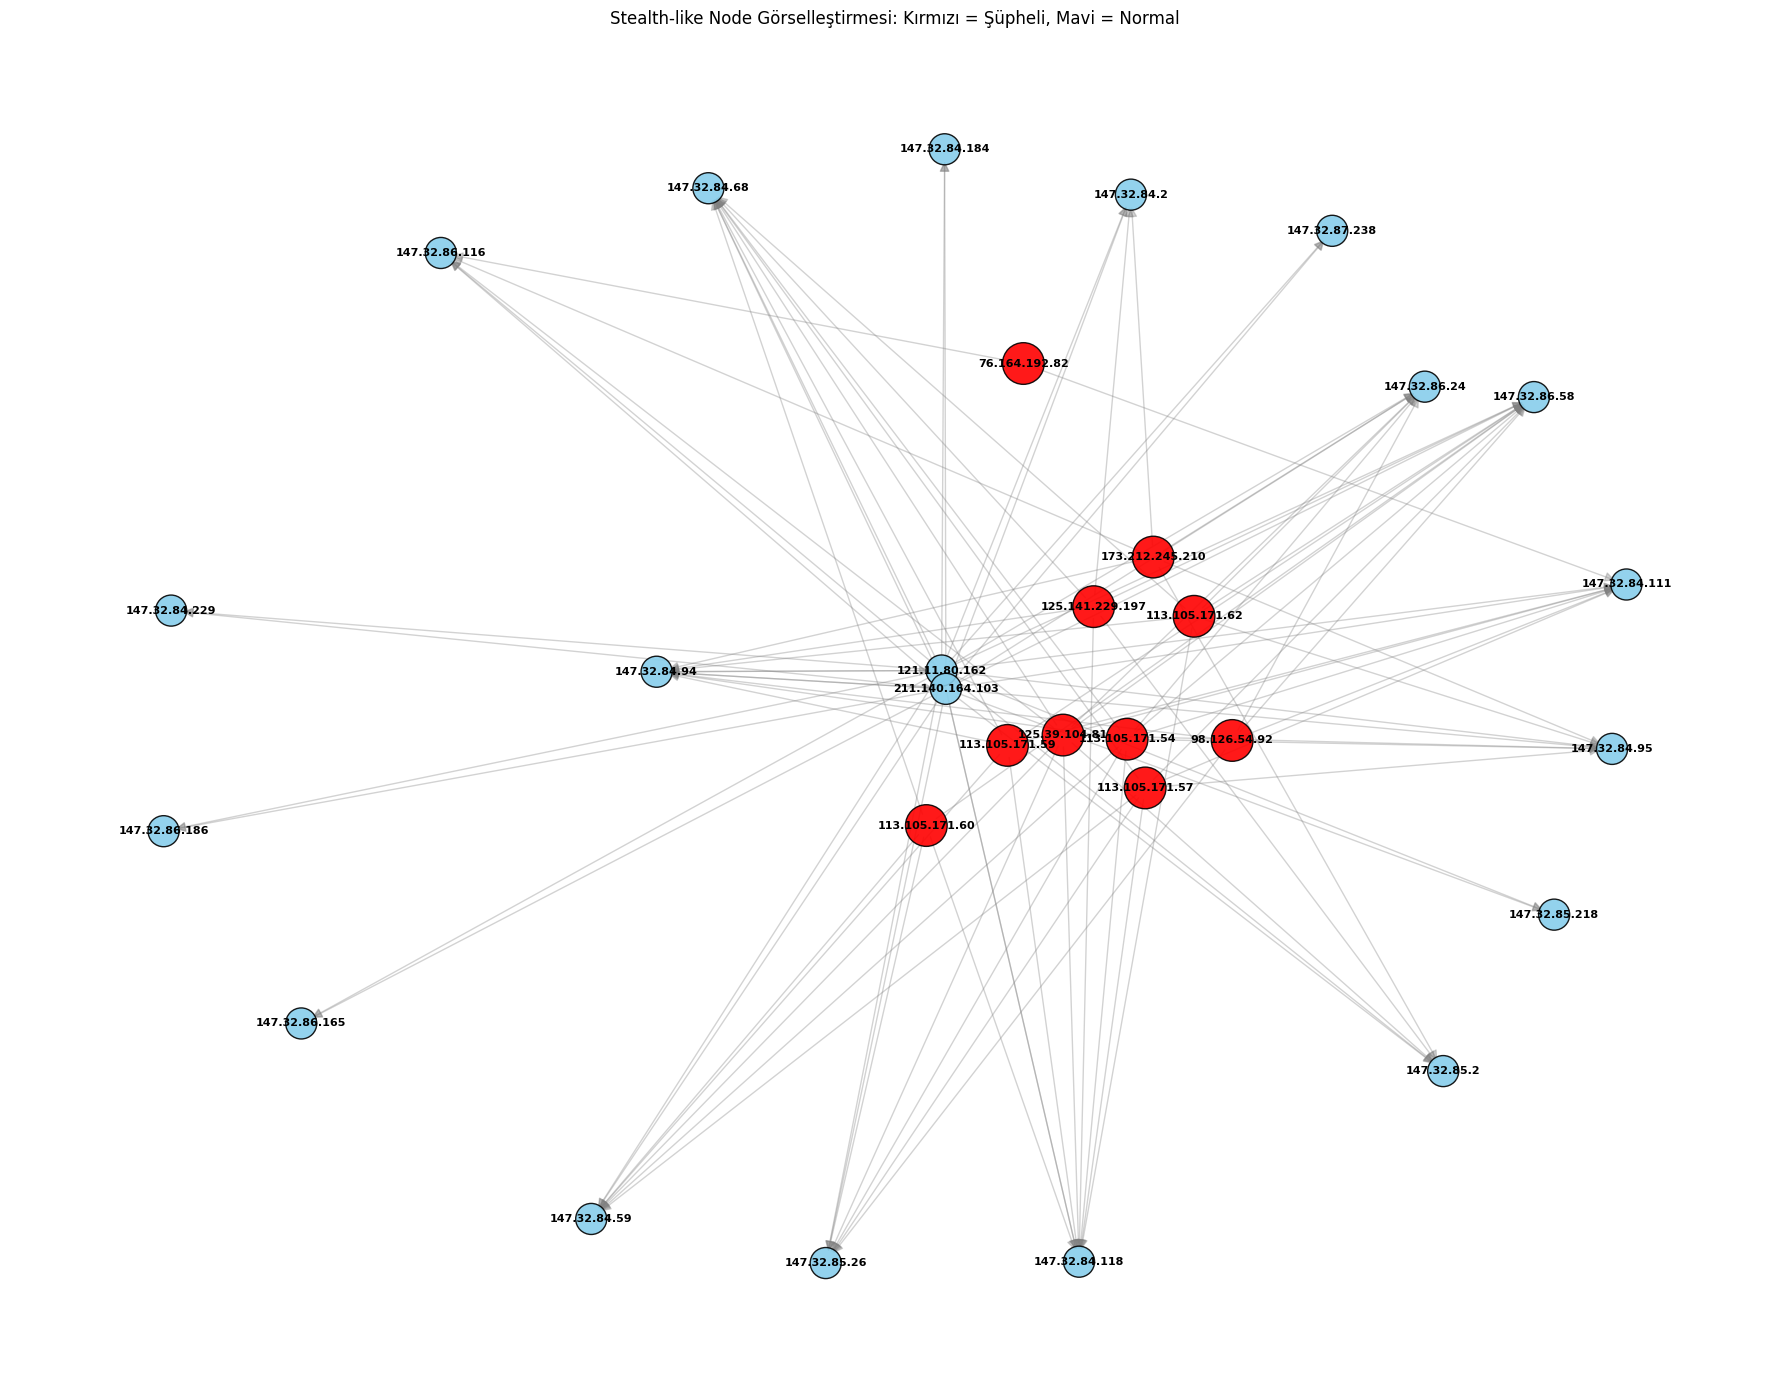

In [40]:
#steath-like node görselleştirme
stealth_nodes = stealth_nodes_df[
    stealth_nodes_df["is_stealth_like"] == 1
]["src_ip"].tolist()

# Görselleştirme için stealth node'lar + yüksek degree node'ları birlikte seçiyoruz
important_nodes = list(set(stealth_nodes[:10] + degree_df.head(20)["node"].tolist()))

stealth_G = G.subgraph(important_nodes).copy()

node_colors = [
    "red" if node in stealth_nodes else "skyblue"
    for node in stealth_G.nodes()
]

node_sizes = [
    900 if node in stealth_nodes else 500
    for node in stealth_G.nodes()
]

plt.figure(figsize=(18, 14))

pos = nx.spring_layout(
    stealth_G,
    k=1.8,
    iterations=150,
    seed=42
)

nx.draw_networkx_nodes(
    stealth_G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="black",
    linewidths=1,
    alpha=0.9
)

nx.draw_networkx_edges(
    stealth_G,
    pos,
    edge_color="gray",
    alpha=0.35,
    arrows=True,
    arrowsize=15
)

nx.draw_networkx_labels(
    stealth_G,
    pos,
    font_size=8,
    font_weight="bold"
)

plt.title("Stealth-like Node Görselleştirmesi: Kırmızı = Şüpheli, Mavi = Normal")
plt.axis("off")
plt.tight_layout()
plt.show()

Grafikte kırmızı düğümler stealth-like davranış adayı olarak işaretlenen IP adreslerini, mavi düğümler ise diğer önemli ağ düğümlerini temsil etmektedir.

Şüpheli düğümlerin ağ içerisinde tamamen izole olmadığı, aksine bazı merkezi IP adresleriyle yoğun bağlantılar kurduğu gözlemlenmektedir. Bu durum stealth-like düğümlerin ağ içerisindeki belirli merkezler üzerinden iletişim kurduğunu göstermektedir.

Bazı kırmızı düğümlerin birden fazla subnet ile bağlantı kurması, bu düğümlerin ağ içerisinde yayılım veya koordinasyon rolü üstlenebileceğini düşündürmektedir.

Ayrıca stealth-like düğümlerin:
- düşük hacimli,
- süreklilik gösteren,
- dağıtık bağlantı yapısına sahip

olması, klasik yoğun trafik üreten saldırı davranışlarından farklı bir örüntü sergilediğini göstermektedir.

In [41]:
processed_data_path = PROCESSED_DATA_DIR / "processed_ctu13_network_data.csv"
edge_data_path = PROCESSED_DATA_DIR / "edge_list_general.csv"
temporal_summary_path = PROCESSED_DATA_DIR / "temporal_network_summary.csv"
centrality_path = PROCESSED_DATA_DIR / "centrality_results.csv"
stealth_path = PROCESSED_DATA_DIR / "stealth_like_nodes.csv"

df.to_csv(processed_data_path, index=False)
edge_df.to_csv(edge_data_path, index=False)
temporal_summary_df.to_csv(temporal_summary_path, index=False)
centrality_df.to_csv(centrality_path, index=False)
stealth_nodes_df.to_csv(stealth_path, index=False)

print("İşlenmiş veri kaydedildi:", processed_data_path)
print("Kenar listesi kaydedildi:", edge_data_path)
print("Zamansal özet kaydedildi:", temporal_summary_path)
print("Merkezilik sonuçları kaydedildi:", centrality_path)
print("Stealth-like node sonuçları kaydedildi:", stealth_path)

İşlenmiş veri kaydedildi: ..\data\processed\processed_ctu13_network_data.csv
Kenar listesi kaydedildi: ..\data\processed\edge_list_general.csv
Zamansal özet kaydedildi: ..\data\processed\temporal_network_summary.csv
Merkezilik sonuçları kaydedildi: ..\data\processed\centrality_results.csv
Stealth-like node sonuçları kaydedildi: ..\data\processed\stealth_like_nodes.csv


## Sonuçlar

Bu notebook kapsamında CTU-13 Botnet Dataset kullanılarak IP adresleri arasındaki bağlantılar yönlü ve ağırlıklı graph yapısına dönüştürülmüştür.

Ağ modelinde:

- Düğümler IP adreslerini,
- Kenarlar IP adresleri arasındaki bağlantıları,
- Kenar ağırlıkları bağlantı sayısını,
- Ek kenar özellikleri ise paket sayısı, byte miktarı ve ortalama bağlantı süresini temsil etmektedir.

İlk aşamada genel ağ grafiği oluşturulmuş ve temel ağ özellikleri incelenmiştir. Daha sonra degree, betweenness, closeness ve PageRank merkezilik ölçütleri hesaplanarak ağdaki merkezi, köprü ve etkili IP adresleri belirlenmiştir.

Veri seti 5 dakikalık zaman pencerelerine ayrılarak zamansal ağ analizi için uygun hale getirilmiştir. Bu sayede ağın zaman içerisindeki düğüm sayısı, kenar sayısı, yoğunluk ve ortalama derece değişimleri incelenmiştir.

Son olarak düşük hacimli fakat süreklilik gösteren bağlantı örüntülerine sahip IP adresleri stealth-like node adayı olarak işaretlenmiştir. Bu çalışma, sonraki notebooklarda yapılacak topluluk analizi, dayanıklılık analizi ve detaylı sonuç yorumları için temel altyapıyı oluşturmuştur.